# Ch2 Lecture 4

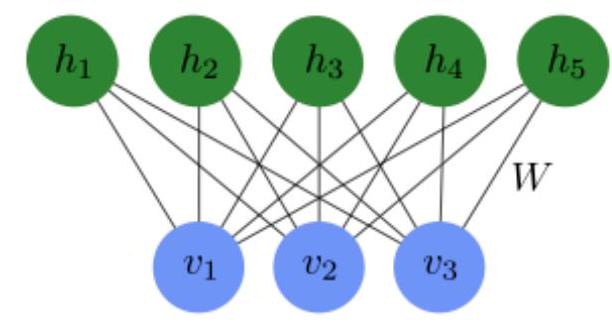
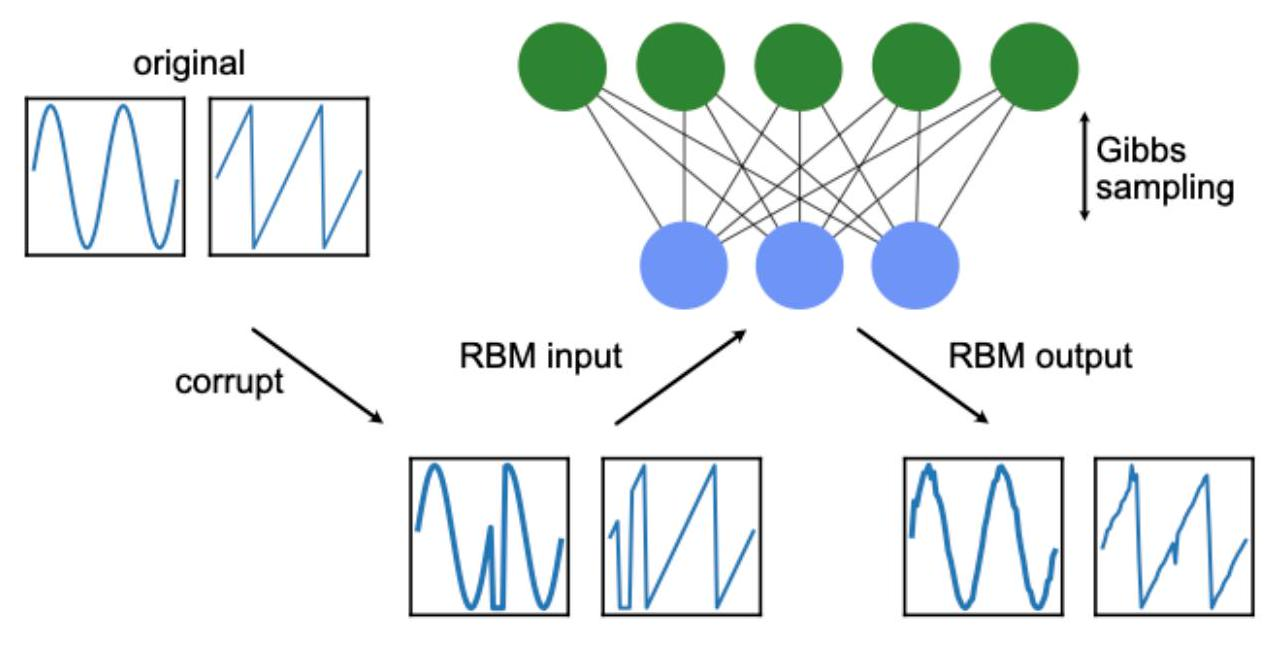
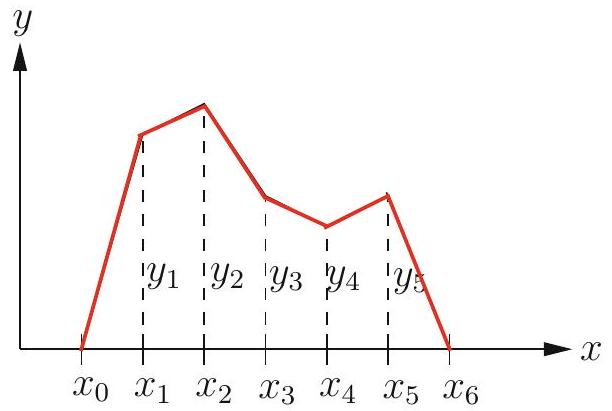

# *MCMC*

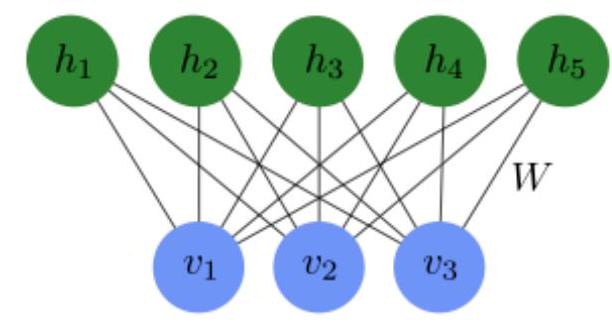
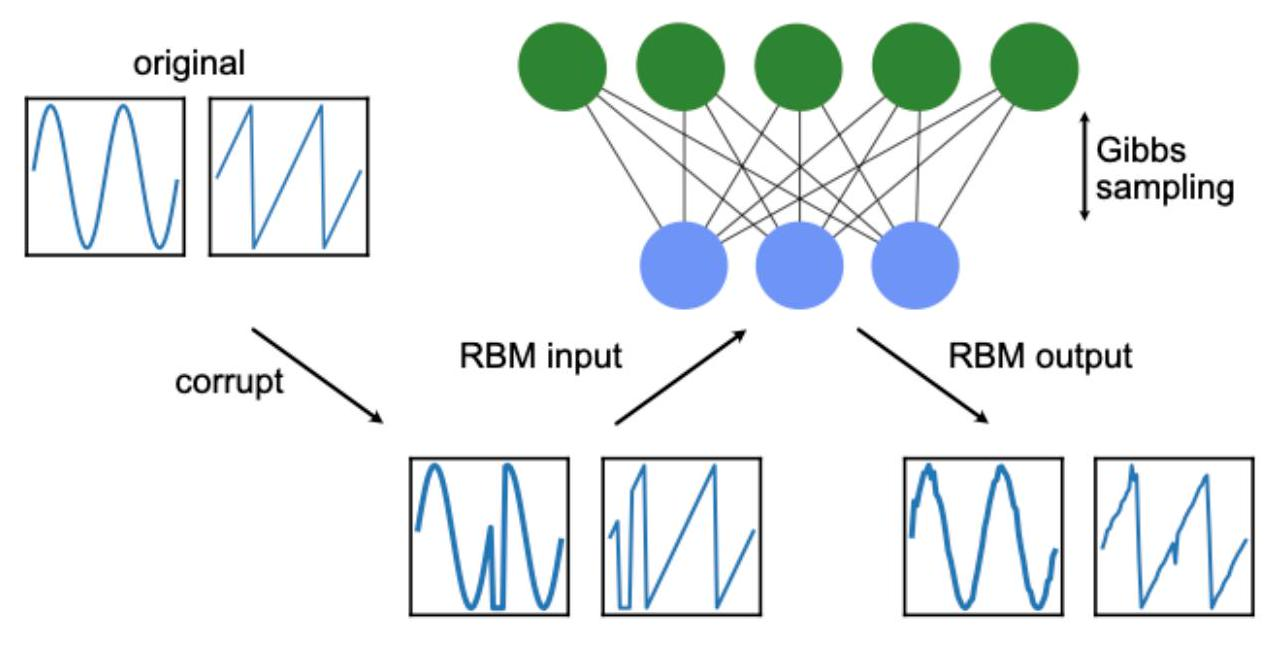
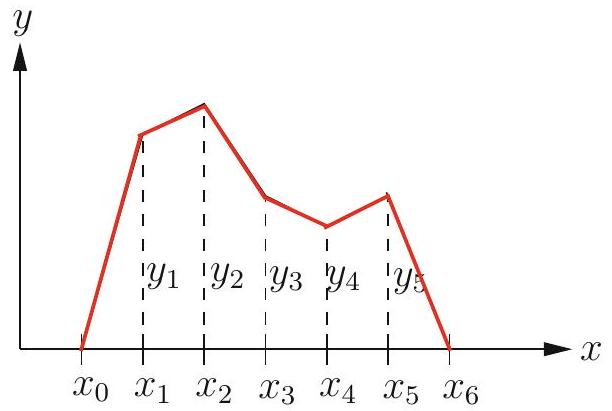

## *Idea of MCMC*

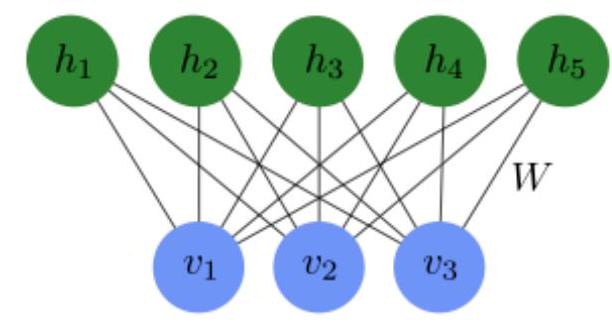
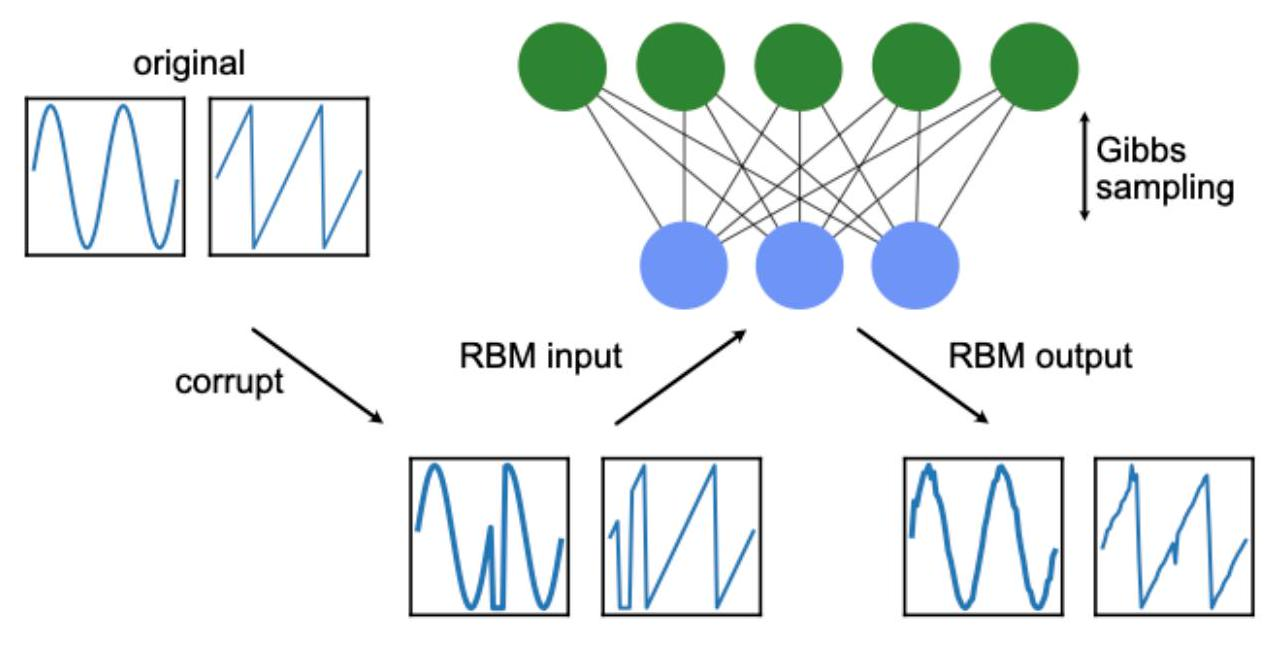
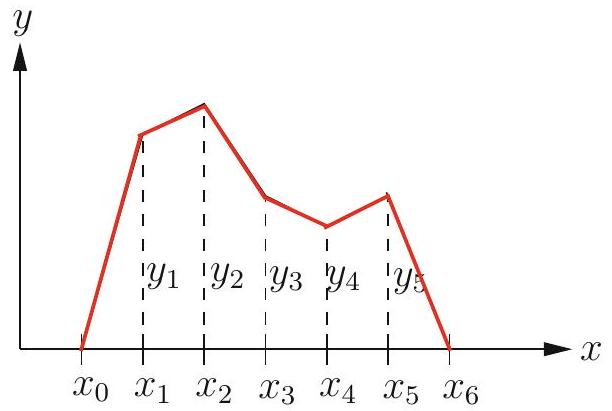

# *Restricted Boltzmann Machine*

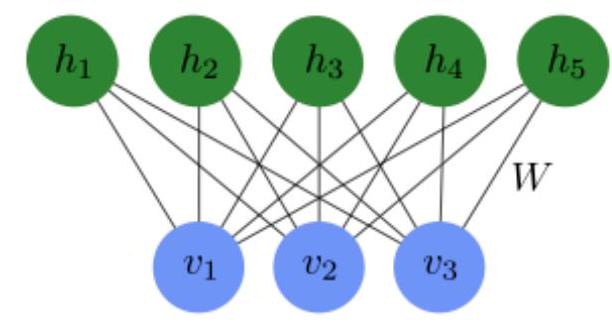
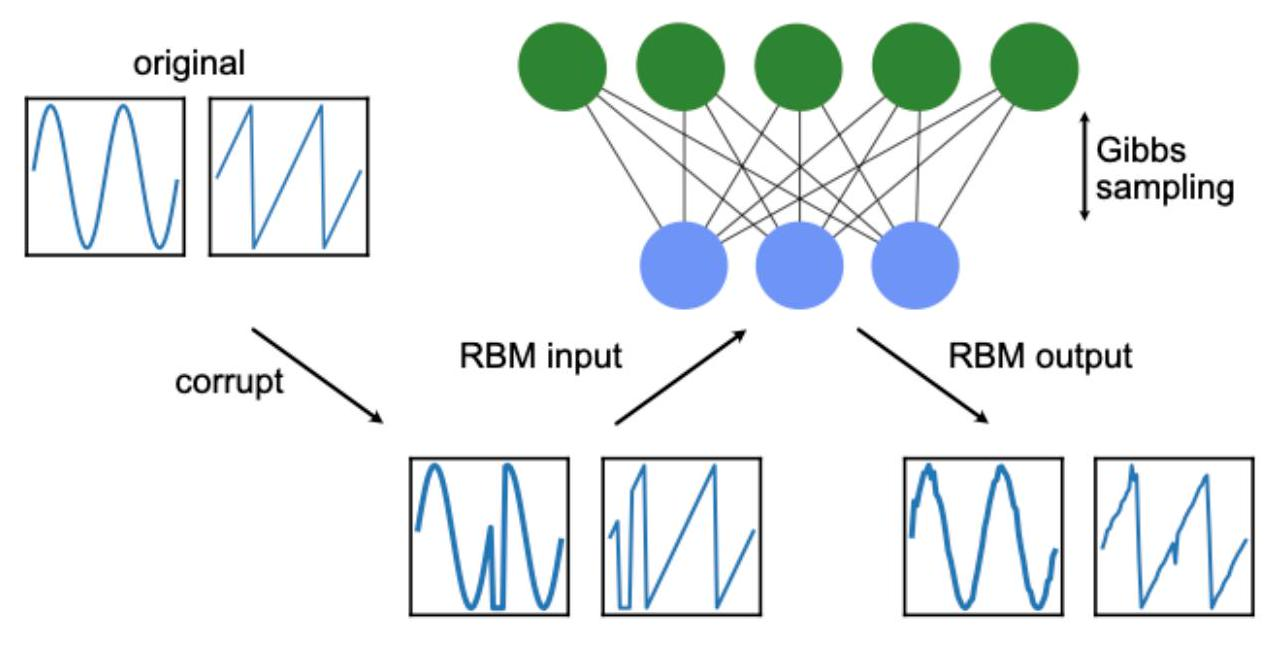
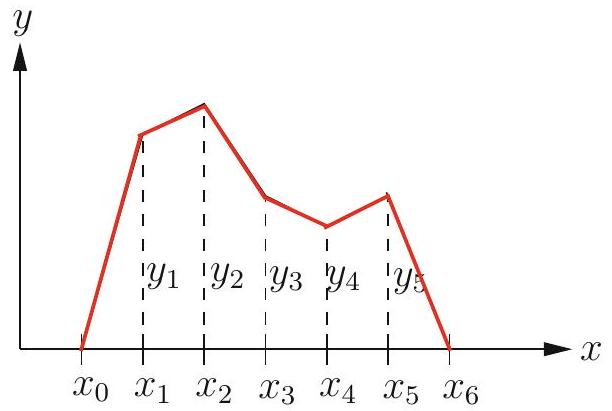

## *Intro to the idea of a Restricted Boltzmann Machine*

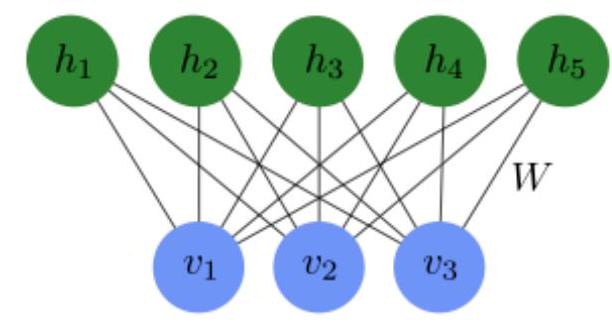
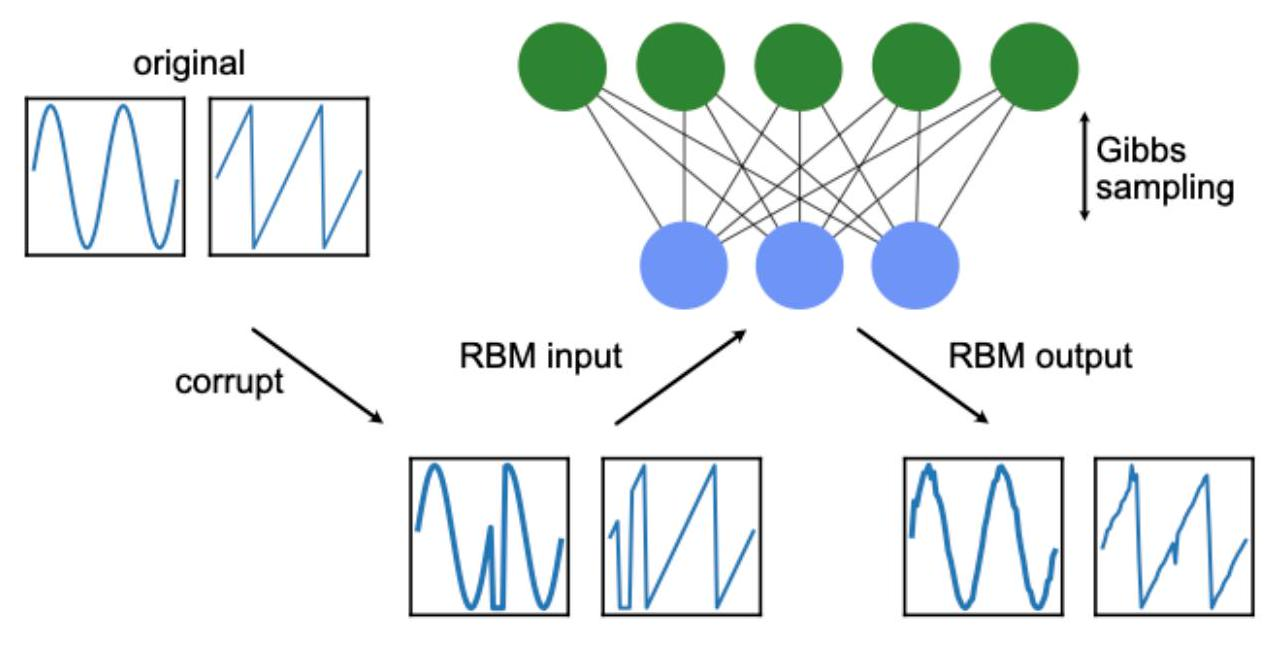
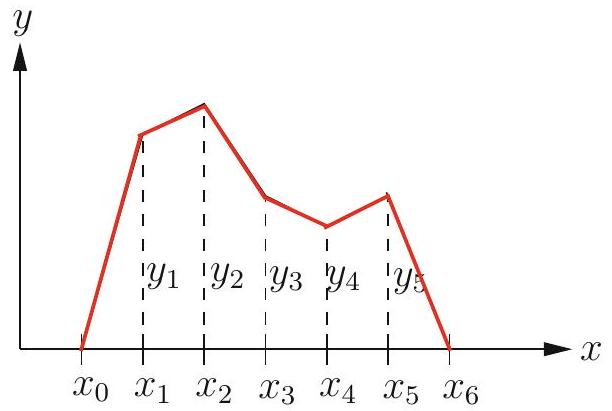

## *Math of the RBM*

From
https://ml-lectures.org/docs/unsupervised_learning/ml_unsupervised-1.html

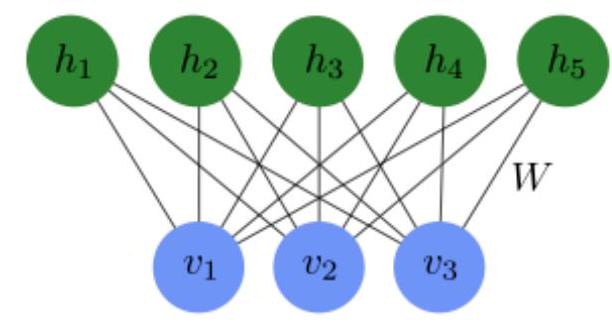

. . .

States are determined by an **energy function**
$E(\mathbf{v}, \mathbf{h})$. $$
E(\mathbf{v}, \mathbf{h})=-\sum_{i} a_{i} v_{i}-\sum_{j} b_{j} h_{j}-\sum_{i j} v_{i} W_{i j} h_{j} 
$$

. . .

Then the probability distribution is given by the Boltzmann
distribution:

$P_{\mathrm{rbm}}(\mathbf{v}, \mathbf{h})=\frac{1}{Z} e^{-E(\mathbf{v}, \mathbf{h})}$
where $Z=\sum_{\mathbf{v}, \mathbf{h}} e^{-E(\mathbf{v}, \mathbf{h})}$

## 

The probability of a visible vector $\mathbf{v}$ is given by
marginalizing over the hidden variables:

$$
P_{\mathrm{rbm}}(\mathbf{v})=\sum_{\mathbf{h}} P_{\mathrm{rbm}}(\mathbf{v}, \mathbf{h})=\frac{1}{Z} \sum_{h} e^{-E(\mathbf{v}, \mathbf{h})}
$$

Conveniently, this gives each visible unit an **independent**
probability of activation:

$$
P_{\mathrm{rbm}}\left(v_{i}=1 | \mathbf{h}\right)=\sigma\left(a_{i}+\sum_{j} W_{i j} h_{j}\right), \quad i=1, \ldots, n_{\mathrm{v}}
$$

## 

The same is true for hidden units, given the visible units:

$$
P_{\mathrm{rbm}}\left(h_{j}=1 | \mathbf{v}\right)=\sigma\left(b_{j}+\sum_{i} v_{i} W_{i j}\right) \quad j=1, \ldots, n_{\mathrm{h}}
$$

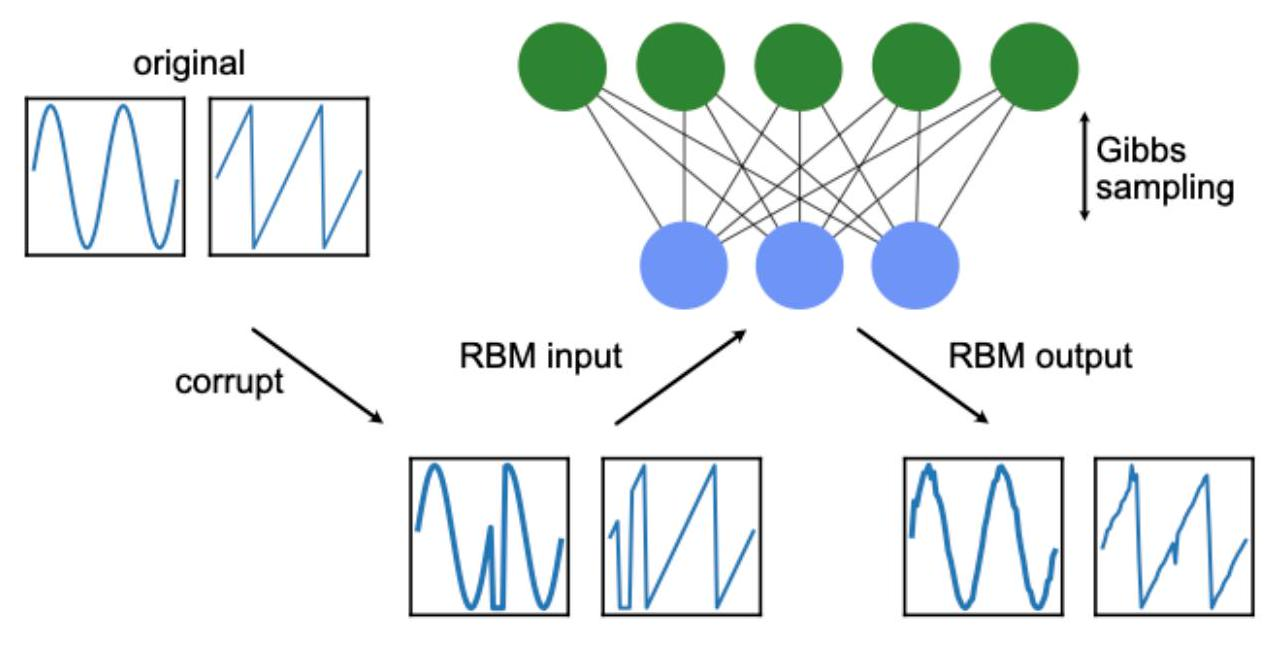
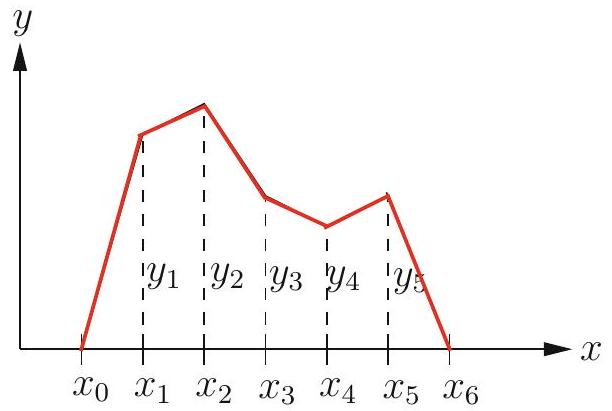

## *Training*

Consider a set of binary input data $\mathbf{x}_{k}, k=1, \ldots, M$,
drawn from a probability distribution $P_{\text {data }}(\mathbf{x})$.

Goal: tune the parameters $\{\mathbf{a}, \mathbf{b}, W\}$ such that
after training
$P_{\mathrm{rbm}}(\mathbf{x}) \approx P_{\mathrm{data}}(\mathbf{x})$.

. . .

To do this, we need to be able to estimate $P_{\mathrm{rbm}}$!

Unfortunately, this is often intractable, because it requires
calculating the partition function $Z$.

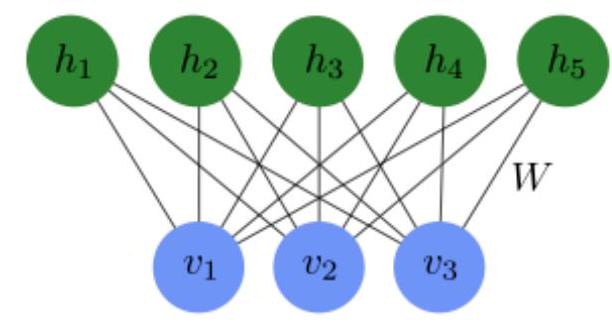
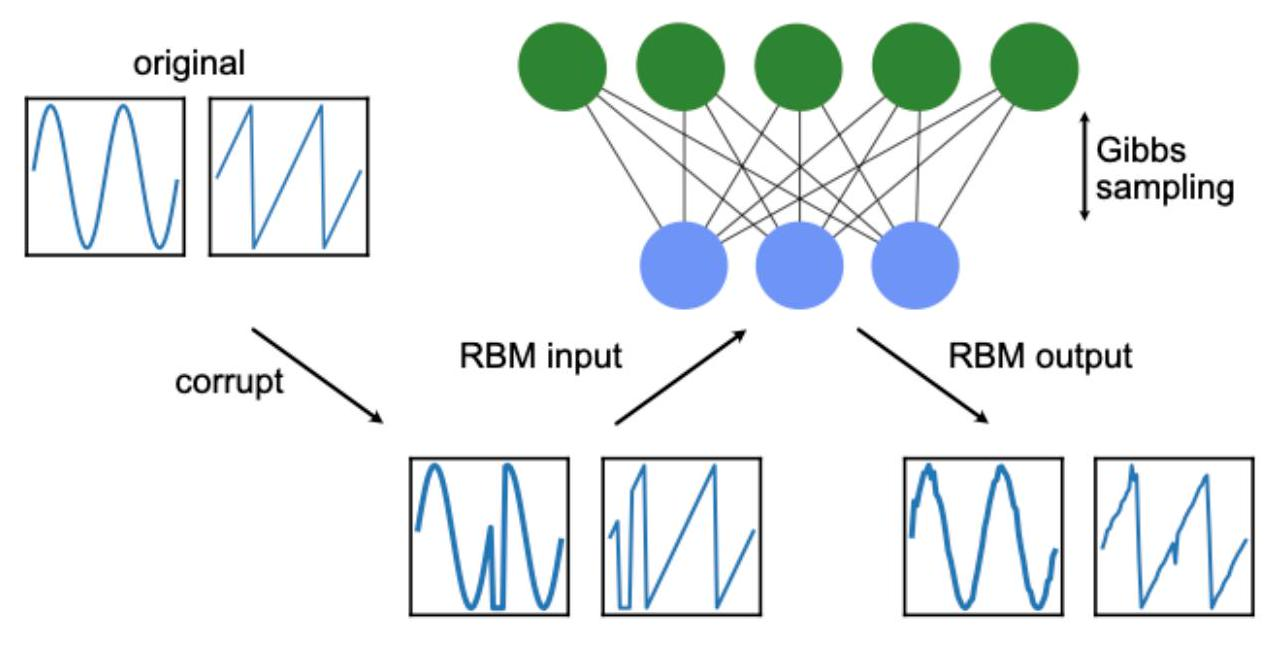
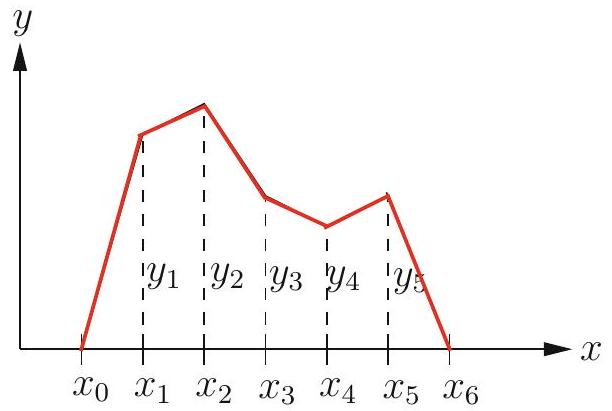

## *Details of the training*

We want to maximize the log-likelihood of the data under the model: $$
L(\mathbf{a}, \mathbf{b}, W)=-\sum_{k=1}^{M} \log P_{\mathrm{rbm}}\left(\mathbf{x}_{k}\right)
$$

. . .

Take derivatives of this with respect to the parameters, and use
gradient descent:

$$
\frac{\partial L(\mathbf{a}, \mathbf{b}, W)}{\partial W_{i j}}=-\sum_{k=1}^{M} \frac{\partial \log P_{\mathrm{rbm}}\left(\mathbf{x}_{k}\right)}{\partial W_{i j}}
$$

## 

The derivative has two terms: $$
\frac{\partial \log P_{\mathrm{rbm}}(\mathbf{x})}{\partial W_{i j}}=x_{i} P_{\mathrm{rbm}}\left(h_{j}=1 |\mathbf{x}\right)-\sum_{\mathbf{v}} v_{i} P_{\mathrm{rbm}}\left(h_{j}=1 | \mathbf{v}\right) P_{\mathrm{rbm}}(\mathbf{v})
$$

. . .

Use this to update the weights:

$$
W_{i j} \rightarrow W_{i j}-\eta \frac{\partial L(a, b, W)}{\partial W_{i j}}
$$

Problem: the second term in the derivative is intractable! It has
$2^{n_{\mathrm{v}}}$ terms:

$$ 
\sum_{\mathbf{v}} v_{i} P_{\mathrm{rbm}}\left(h_{j}=1 | \mathbf{v}\right) P_{\mathrm{rbm}}(\mathbf{v}) 
$$

Instead, we will use **Gibbs sampling** to estimate
$P_{\mathrm{rbm}}(\mathbf{v})$.

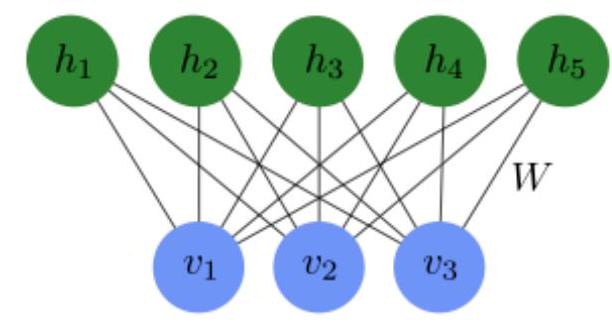
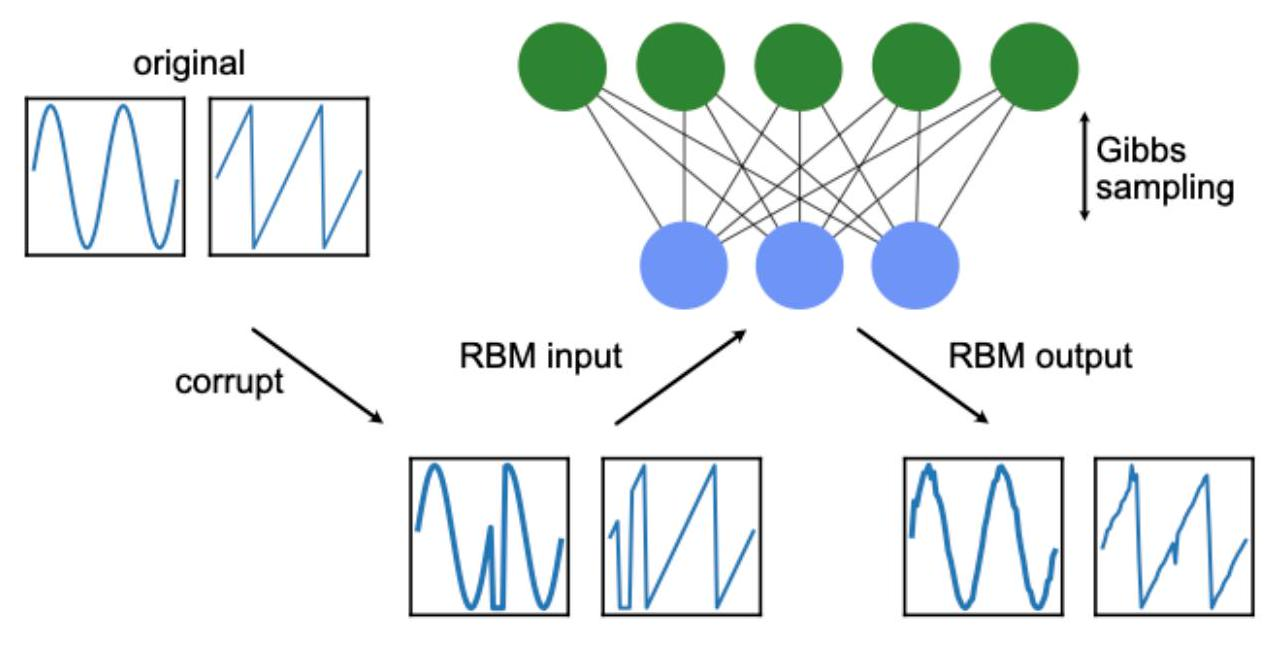
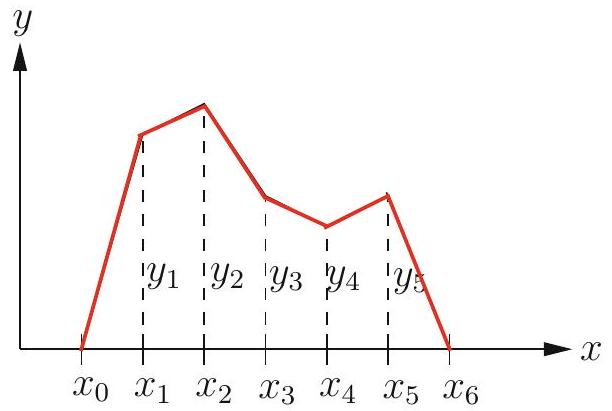

## *Gibbs sampling to the rescue*

Input: Any visible vector $\mathbf{v}(0)$

Output: Visible vector $\mathbf{v}(r)$

for: $n=1 \backslash$ dots $r$

$\operatorname{sample} \mathbf{h}(n)$ from
$P_{\mathrm{rbm}}(\mathbf{h} \mathbf{v}=\mathbf{v}(n-1))$

sample $\mathbf{v}(n)$ from
$P_{\mathrm{rbm}}(\mathbf{v} \mathbf{h}=\mathbf{h}(n))$ end

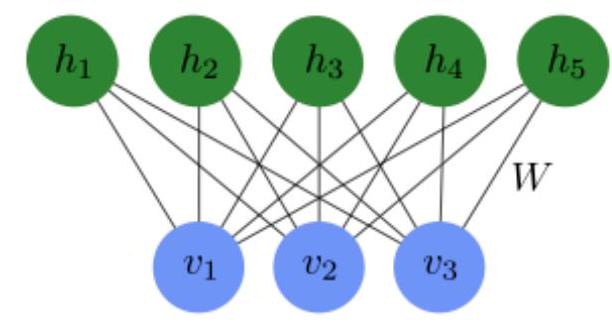
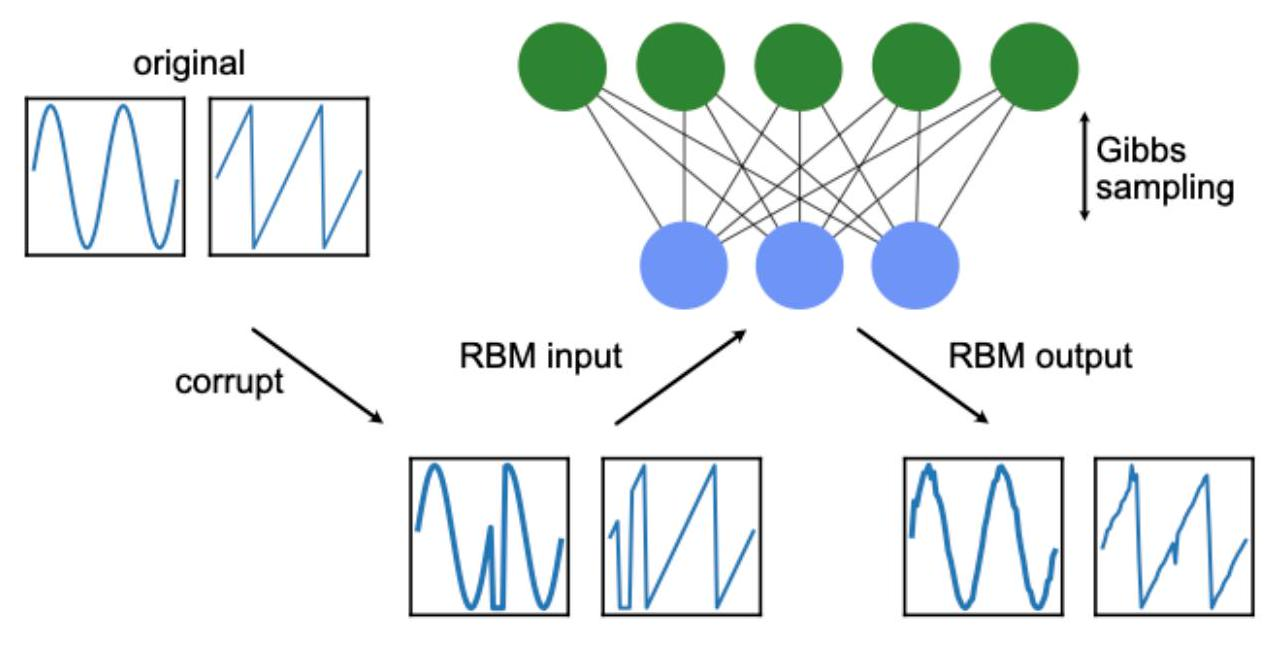
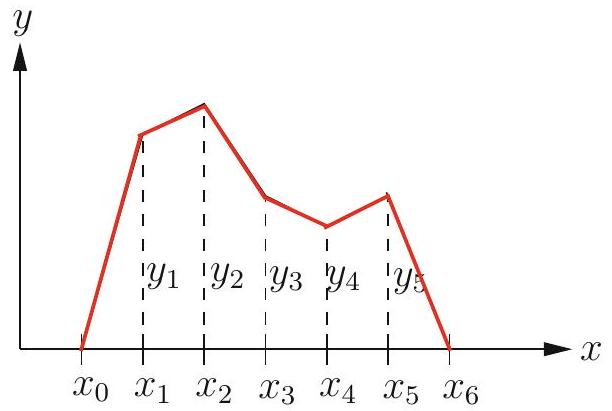

## *Using an RBM*

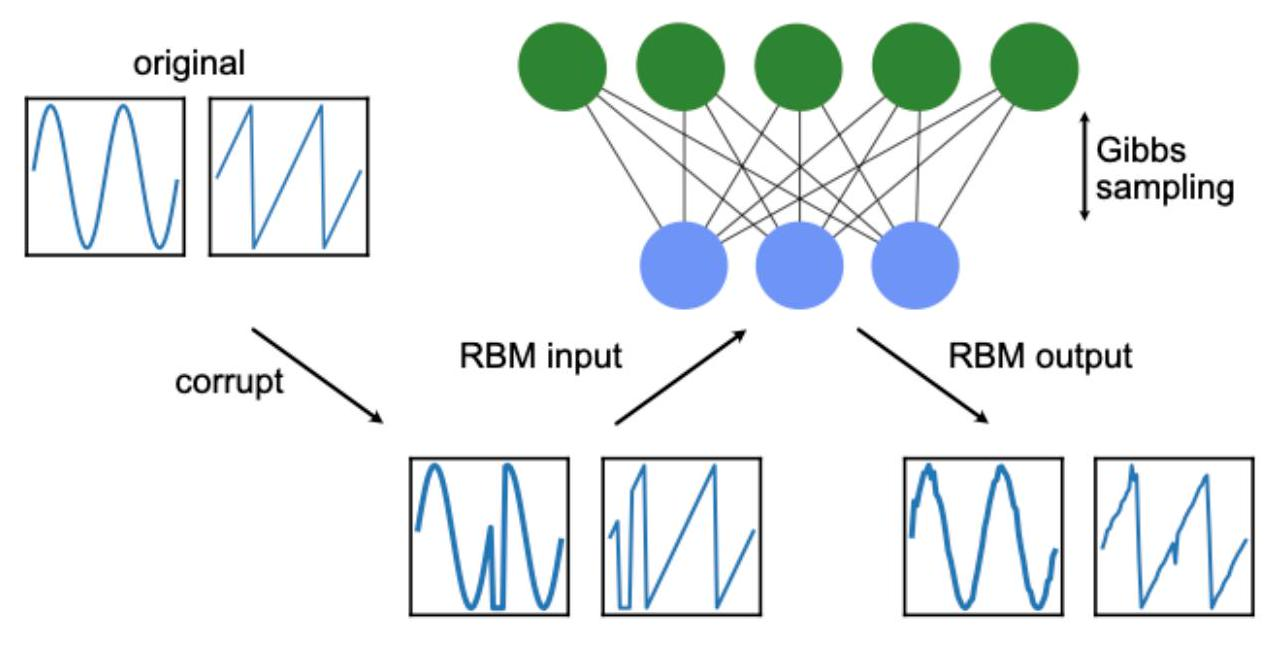

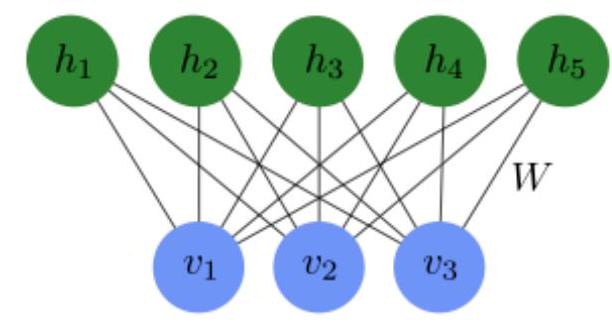
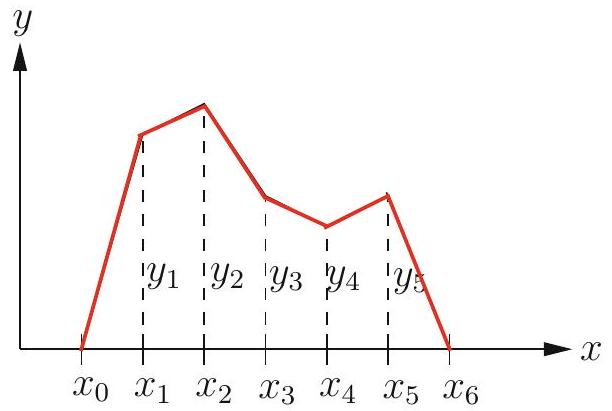

# *LU Factorization*

## 

Suppose we want to solve a nonsingular linear system $A x=b$ repeatedly,
with different choices of $b$.

. . .

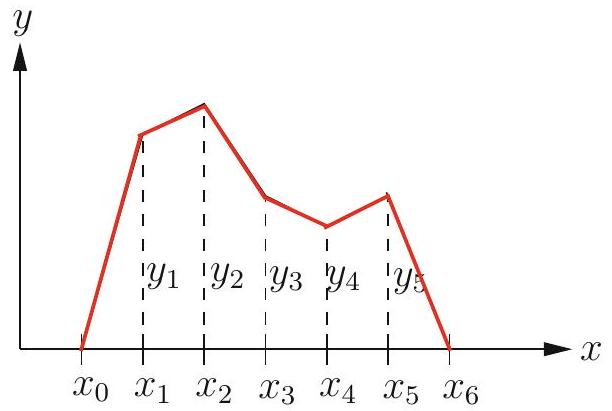

$$
-y_{i-1}+2 y_{i}-y_{i+1}=\frac{h^{2}}{K} f\left(x_{i}\right), i=1,2, \ldots, n
$$

. . .

Perhaps you want to experiment with different functions for the heat
source term.

. . .

What do we do? Each time, we create the augmented matrix
$\widetilde{A}=[A \mid b]$, then get it into reduced row echelon form.

. . .

Each time change $b$, we have to redo all the work of Gaussian or
Gauss-Jordan elimination !

. . .

Especially frustrating because the main part of our work is the same:
putting the part of $\widetilde{A}$ corresponding to the coefficient
matrix $A$ into reduced row echelon form.

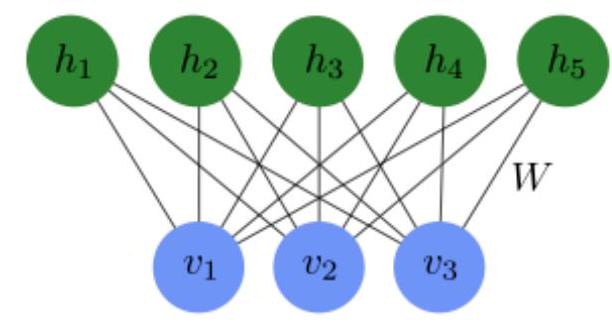
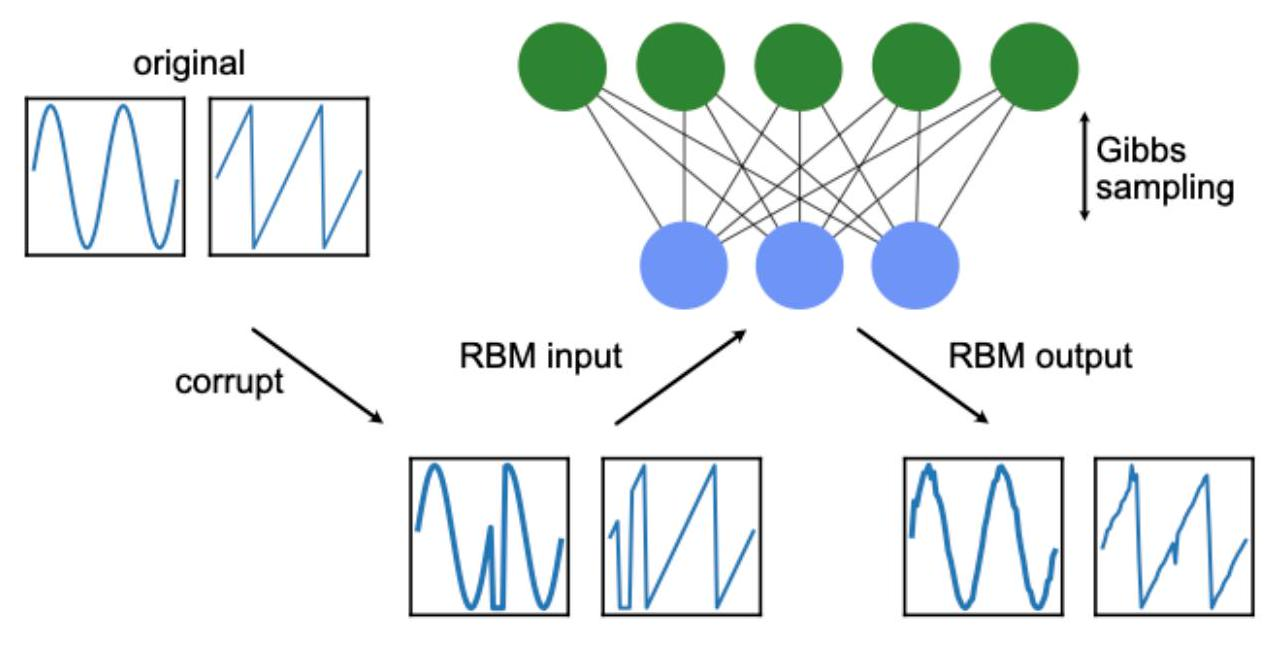

## *LU Factorization: Saving that work*

Goal: Find a way to record our work on $A$, so that solving a new system
involves very little additional work.

LU Factorization: Let $A$ be an $n \times n$ matrix. An LU factorization
of $A$ is a pair of $n \times n$ matrices $L, U$ such that

1.  $L$ is lower triangular.
2.  $U$ is upper triangular.
3.  $A=L U$.

. . .

Why is this so wonderful? Triangular systems $A \mathbf{x}=\mathbf{b}$
are easy to solve.

Remember: If $A$ is upper triangular, we can solve for the last
variable, then the next-to-last variable, etc.

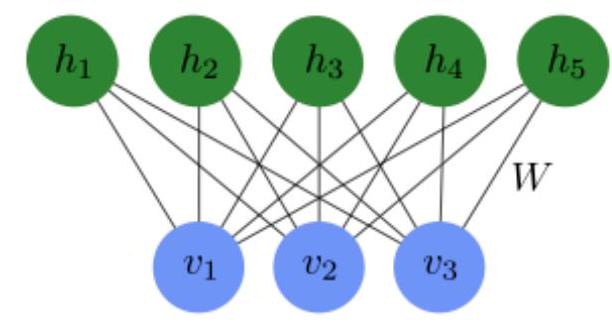
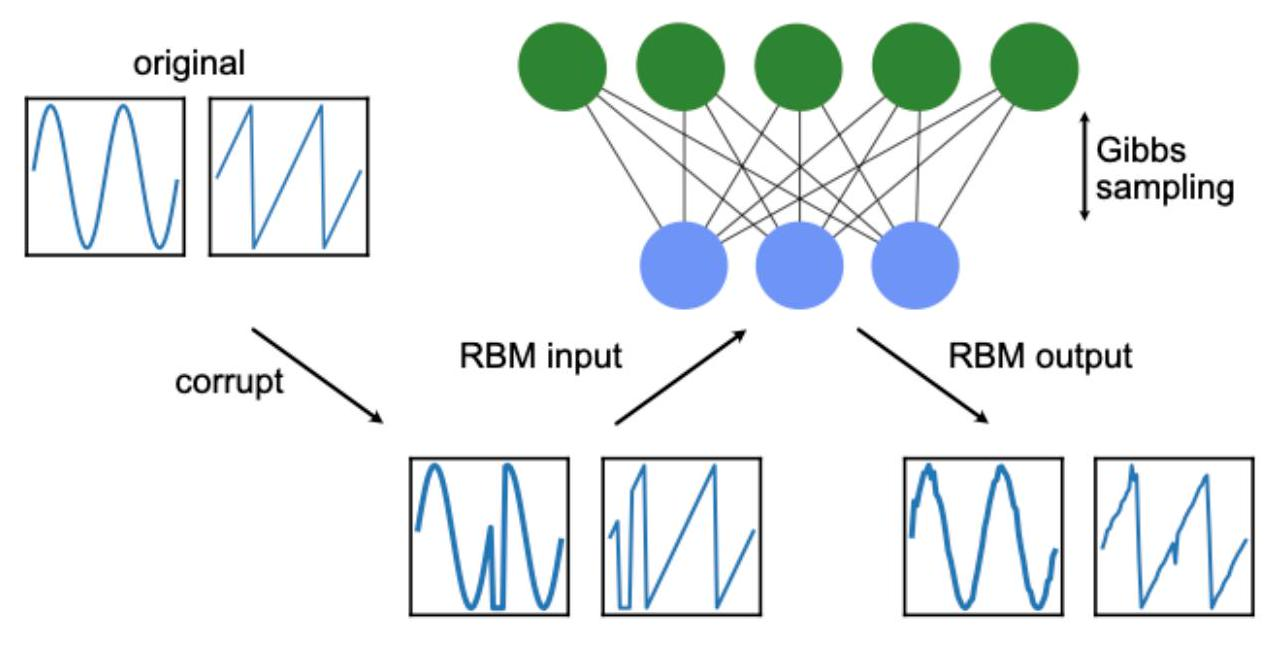
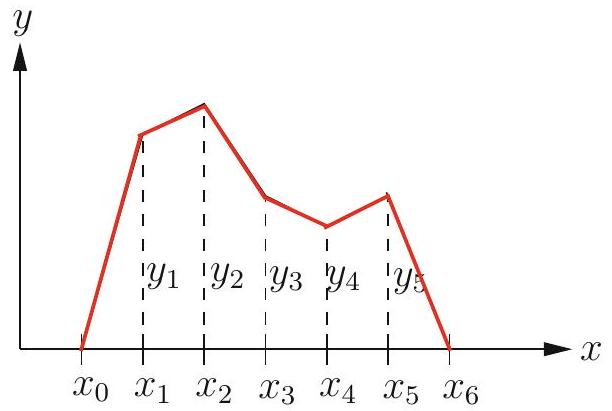

## *Solving an upper triangular system*

Let’s say we have the following system:

$A x = b$ where A is the upper-triangular matrix
$A = \begin{bmatrix} 2 & 1 & 0 \\ 0 & 1 & -1 \\ 0 & 0 & -1 \end{bmatrix}$,
and we want to solve for
$b = \begin{bmatrix} 1 \\ 1 \\ -2 \end{bmatrix}$.

. . .

We form the augmented matrix
$\widetilde{A} = [A | b] = \begin{bmatrix} 2 & 1 & 0 & | & 1 \\ 0 & 1 & -1 & | & 1 \\ 0 & 0 & -1 & | & -2 \end{bmatrix}$.

. . .

Back substitution:

1.  Last equation: $-x_3 = -2$, so $x_3 = 2$.
2.  Substitute this value into the second equation, $x_2 - x_3 = 1$, so
    $x_2 = 3$.
3.  Finally, we substitute $x_2$ and $x_3$ into the first equation,
    $2x_1 + x_2 = 1$, so $x_1 = -1$.

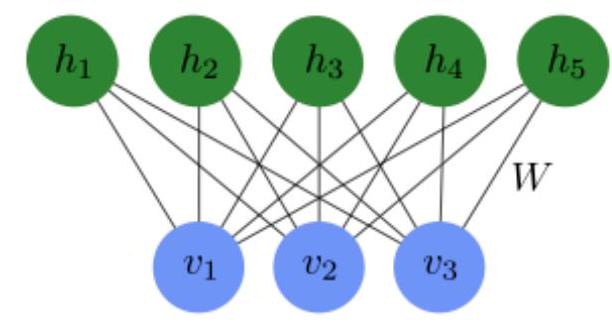
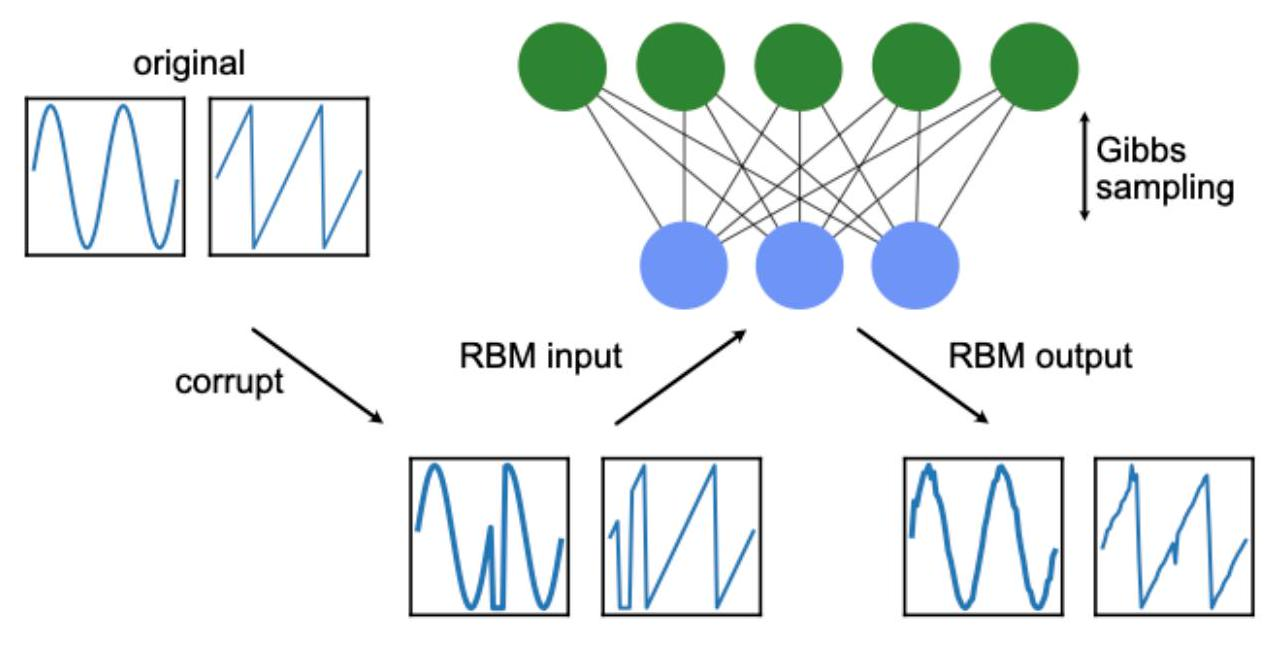
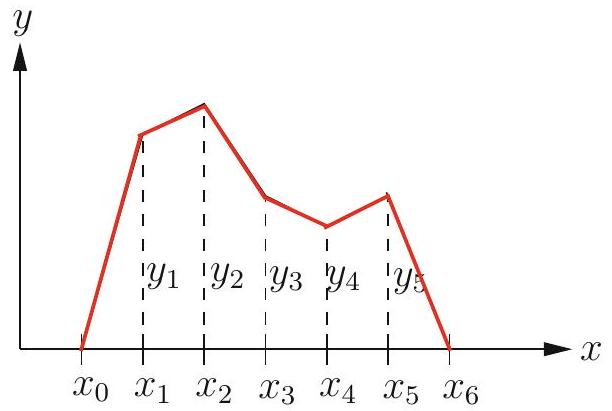

## *Solving a lower triangular system*

If $A$ is lower triangular, we can solve for the first variable, then
the second variable, etc.

Let’s say we have the following system:

$A y = b$ where A is the lower-triangular matrix
$A = \begin{bmatrix} 1 & 0 & 0 \\ -1 & 1 & 0 \\ 1 & 2 & 1 \end{bmatrix}$,
and we want to solve for
$b = \begin{bmatrix} 1 \\ 0 \\ 1 \end{bmatrix}$.

. . .

We form the augmented matrix
$\widetilde{A} = [A | b] = \begin{bmatrix} 1 & 0 & 0 & | & 1 \\ -1 & 1 & 0 & | & 0 \\ 1 & 2 & 1 & | & 1 \end{bmatrix}$.

. . .

Forward substitution:

1.  First equation: $y_1 = 1$.
2.  Substitute this value into the second equation, $-y_1 + y_2 = 0$, so
    $y_2 = 1$.
3.  Finally, we substitute $y_1$ and $y_2$ into the third equation,
    $y_1 + 2y_2 + y_3 = 1$, so $y_3 = -2$.

. . .

This was just as easy as solving the upper triangular system!

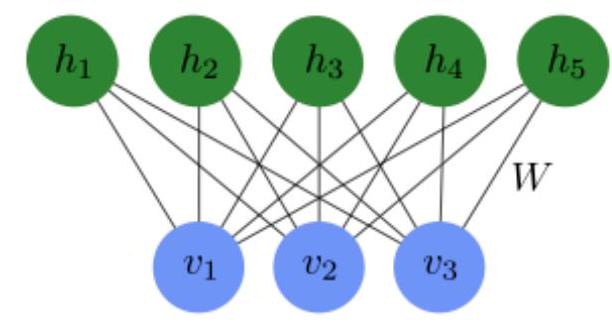
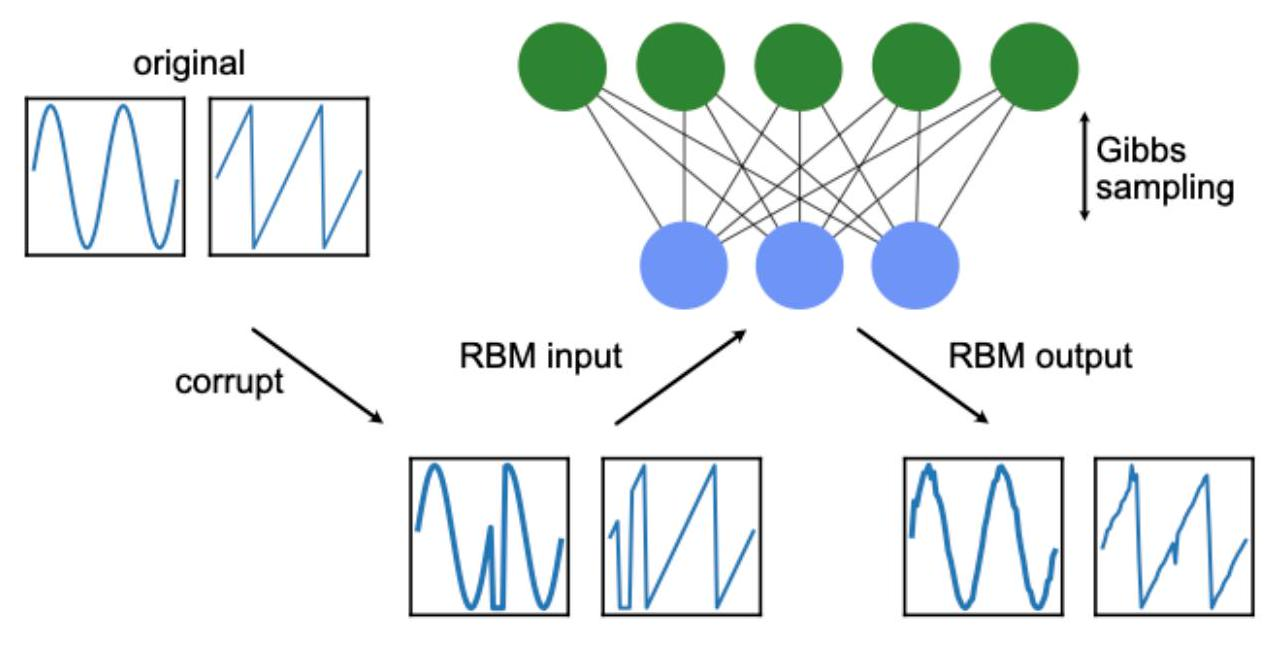
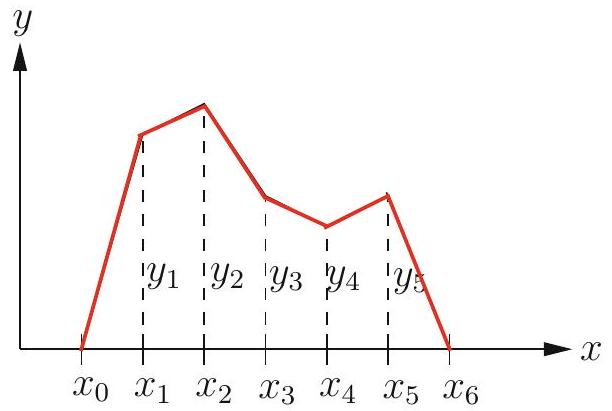

## *Solving $A x = b$ with LU factorization*

Now suppose we want to solve $A x = b$ and we know that $A = L U$. The
original system becomes $L U x = b$.

Introduce an intermediate variable $y = U x$. Our system is now
$L y = b$. Now perform these steps:

1.  **Forward solve**: Solve lower triangular system $L y = b$ for the
    variable $y$.
2.  **Back solve**: Solve upper triangular system $U x = y$ for the
    variable $x$.
3.  This does it!

. . .

Once we have the matrices $L, U$, the right-hand sides only come when
solving the two triangular systems. Easy!

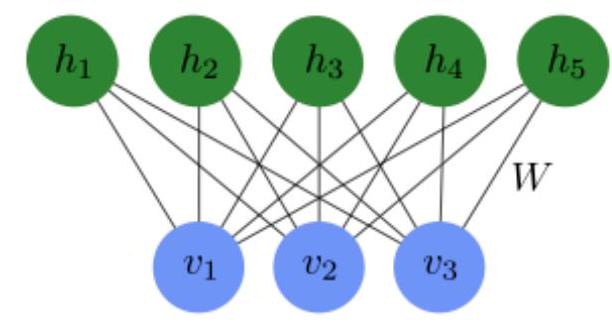
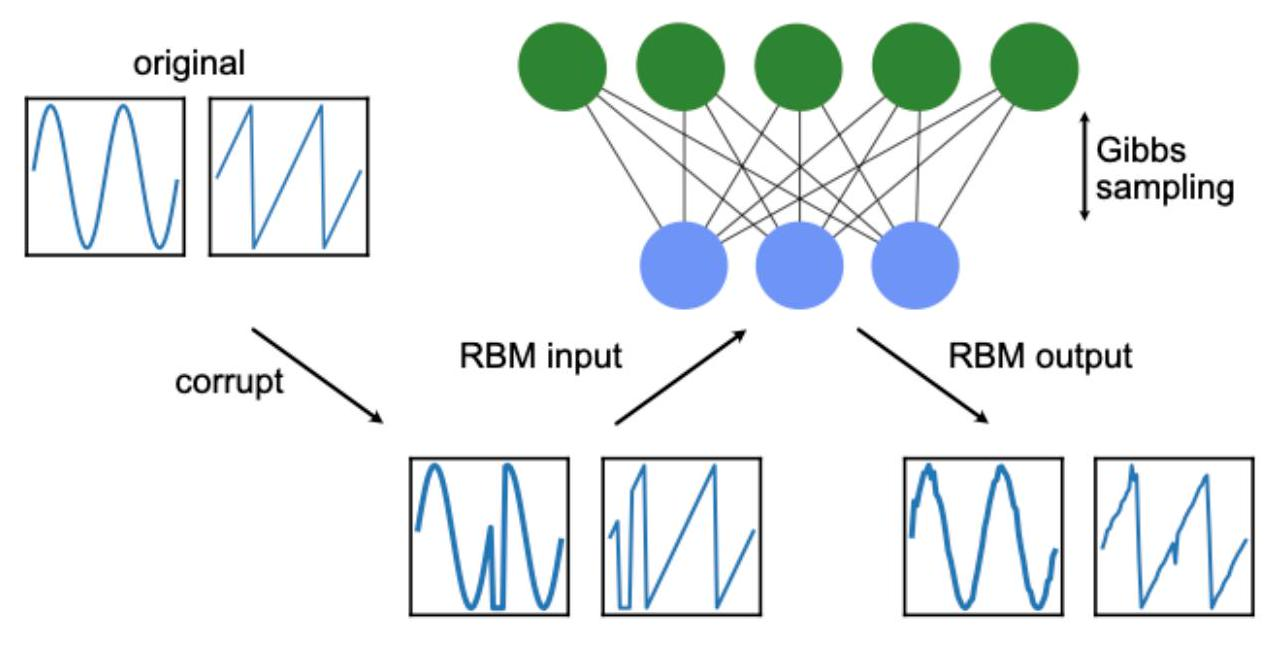
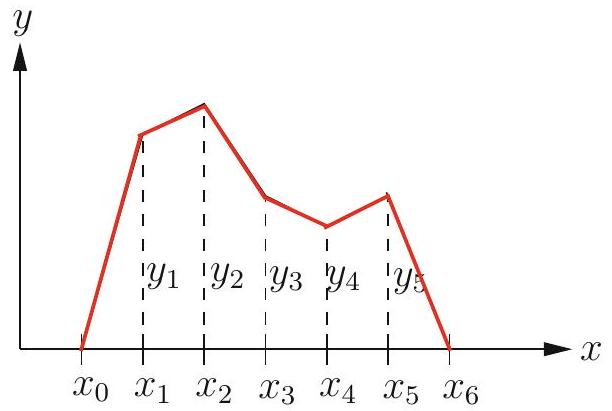

## *Example*

You are given that

$$
A=\left[\begin{array}{rrr}
2 & 1 & 0 \\
-2 & 0 & -1 \\
2 & 3 & -3
\end{array}\right]=\left[\begin{array}{rrr}
1 & 0 & 0 \\
-1 & 1 & 0 \\
1 & 2 & 1
\end{array}\right]\left[\begin{array}{rrr}
2 & 1 & 0 \\
0 & 1 & -1 \\
0 & 0 & -1
\end{array}\right] .
$$

Solve this system for
$\mathbf{b} = \begin{bmatrix} 1 \\ 0 \\ 1 \end{bmatrix}$.

. . .

Forward solve: $$
\left[\begin{array}{rrr}
1 & 0 & 0 \\
-1 & 1 & 0 \\
1 & 2 & 1
\end{array}\right]\left[\begin{array}{l}
y_{1} \\
y_{2} \\
y_{3}
\end{array}\right]=\left[\begin{array}{l}
1 \\
0 \\
1
\end{array}\right]
$$

$y_{1}=1$, then $y_{2}=0+1 y_{1}=1$, then $y_{3}=1-1 y_{1}-2 y_{2}=-2$.

Back solve:

$$
\left[\begin{array}{rrr}
2 & 1 & 0 \\
0 & 1 & -1 \\
0 & 0 & -1
\end{array}\right]\left[\begin{array}{l}
x_{1} \\
x_{2} \\
x_{3}
\end{array}\right]=\left[\begin{array}{r}
1 \\
1 \\
-2
\end{array}\right]
$$

$x_{3}=-2 /(-1)=2$, then $x_{2}=1+x_{3}=3$, then
$x_{1}=\left(1-1 x_{2}\right) / 2=-1$.

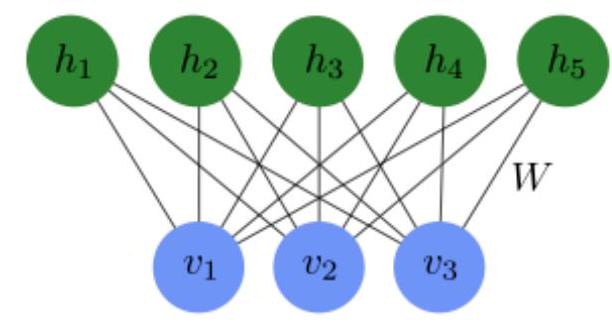
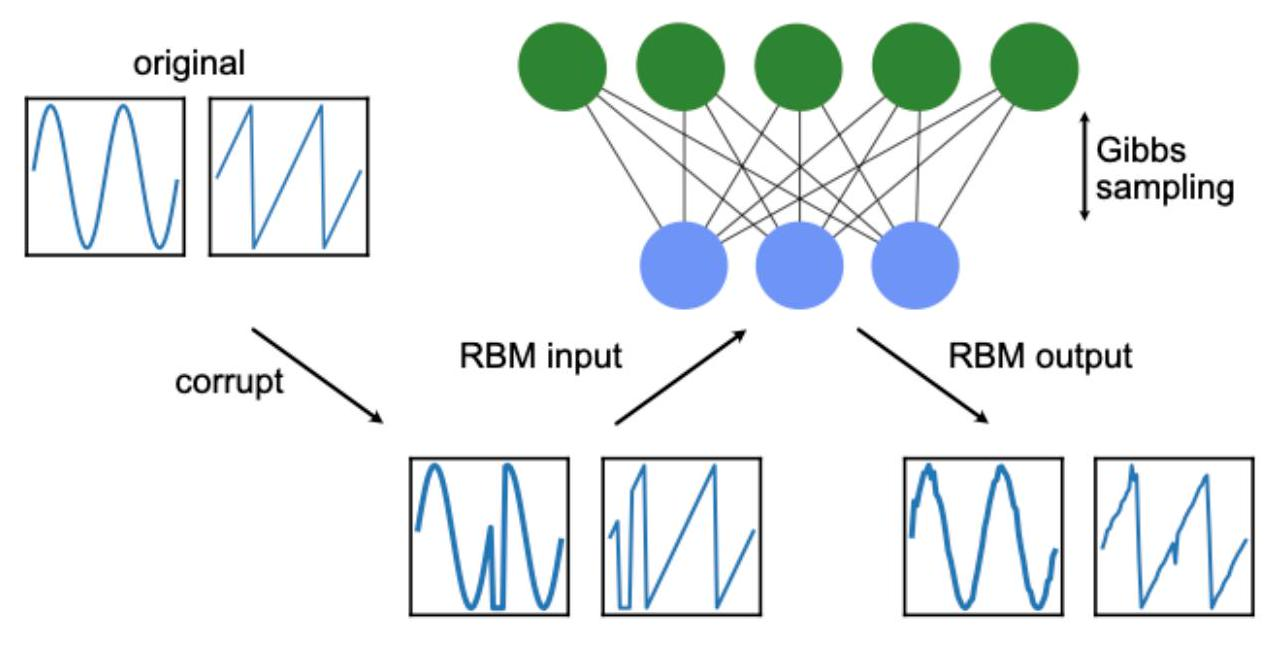
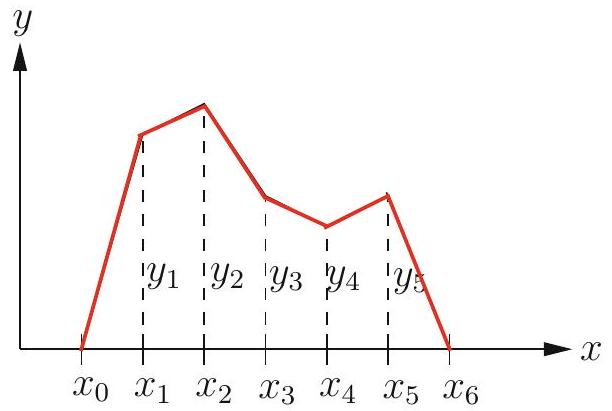

## *When we can do LU factorization*

-   Not all square matrices have LU factorizations! This one doesn’t:
    $\left[\begin{array}{ll}0 & 1 \\ 1 & 0\end{array}\right]$
-   If Gaussian elimination can be performed on the matrix $A$ **without
    row exchanges**, then the factorization exists
    -   (it’s really a by-product of Gaussian elimination.)
-   If row exchanges are needed, there is still a factorization that
    will work, but it’s a bit more complicated.

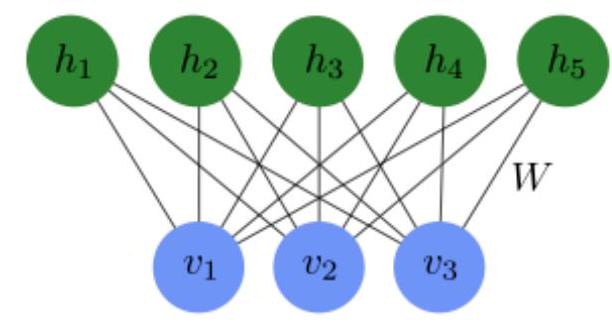
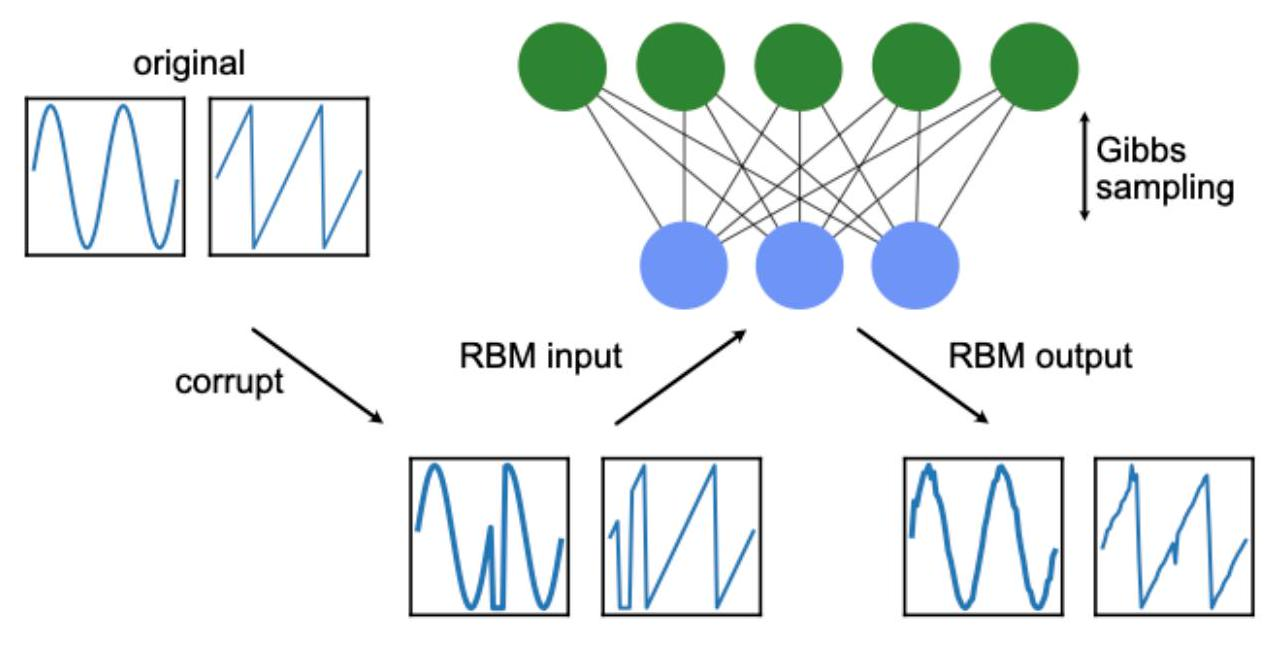
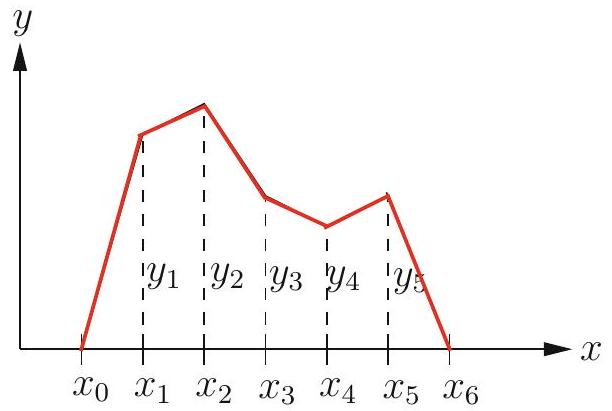

## *Intuition behind LU factorization*

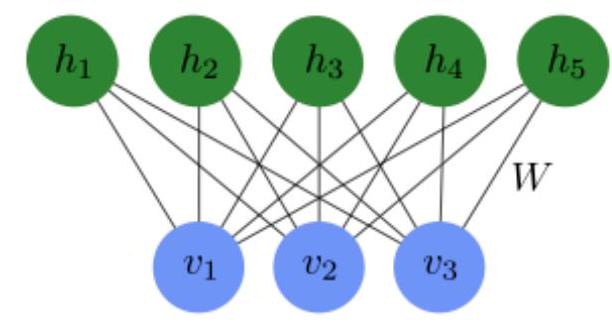
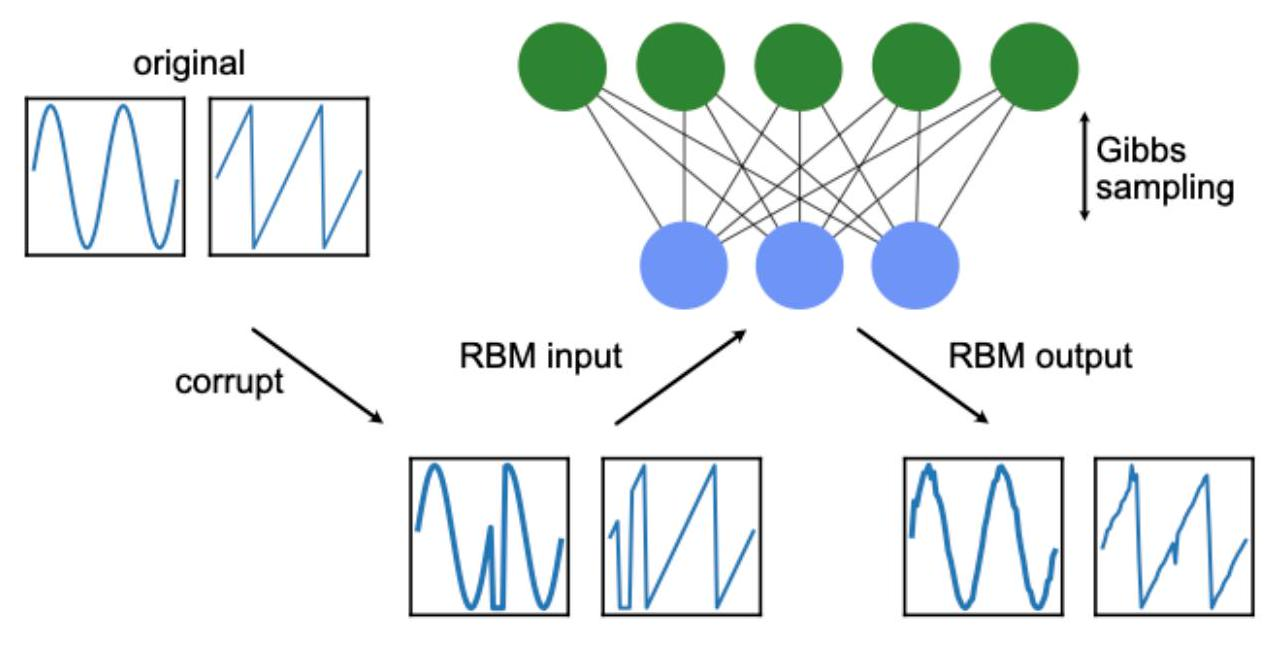
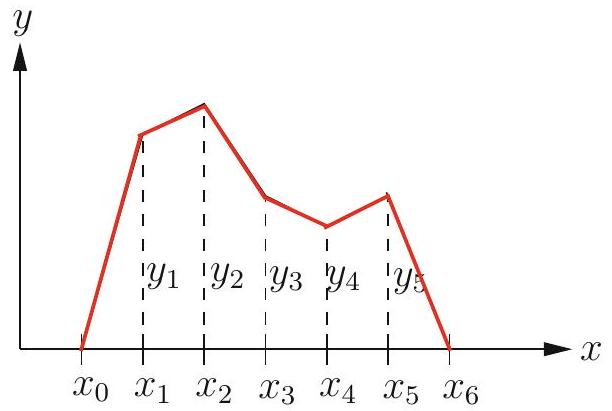

## *Example*

Here we do Gaussian elimination on the matrix
$A = \begin{bmatrix} 2 & 1 & 0 \\ -2 & 0 & -1 \\ 2 & 3 & -3 \end{bmatrix}$:

$\left[\begin{smallmatrix}2 & 1 & 0\\-2 & 0 & -1\\2 & 3 & -3\end{smallmatrix}\right]$
$\xrightarrow[E_{31}(-1)]{E_{21}(1)}$
$\left[\begin{smallmatrix}2 & 1 & 0\\0 & 1 & -1\\0 & 2 & -3\end{smallmatrix}\right]$
$\xrightarrow[E_{32}(-2)]{\longrightarrow}$
$\left[\begin{smallmatrix}2 & 1 & 0\\0 & 1 & -1\\0 & 0 & -1\end{smallmatrix}\right]$

Let’s put those elementary row operations into matrix form. There were
three of them:

1.  $E_{21}(1)$ :
    $\begin{bmatrix} 1 & 0 & 0 \\ 1 & 1 & 0 \\ 0 & 0 & 1 \end{bmatrix}$
2.  $E_{31}(-1)$:
    $\begin{bmatrix} 1 & 0 & 0 \\ 0 & 1 & 0 \\ -1 & 0 & 1 \end{bmatrix}$
3.  $E_{32}(-2)$:
    $\begin{bmatrix} 1 & 0 & 0 \\ 0 & 1 & 0 \\ 0 & -2 & 1 \end{bmatrix}$

The **inverses** of these matrices are

1.  $\begin{bmatrix} 1 & 0 & 0 \\ -1 & 1 & 0 \\ 0 & 0 & 1 \end{bmatrix}$,
    $\begin{bmatrix} 1 & 0 & 0 \\ 0 & 1 & 0 \\ 1 & 0 & 1 \end{bmatrix}$,
    and
    $\begin{bmatrix} 1 & 0 & 0 \\ 0 & 1 & 0 \\ 0 & 2 & 1 \end{bmatrix}$.

## 

The product of all these matrices is

$$
\left[\begin{matrix}1 & 0 & 0\\0 & 1 & 0\\-1 & 0 & 1\end{matrix}\right]\left[\begin{matrix}1 & 0 & 0\\1 & 1 & 0\\0 & 0 & 1\end{matrix}\right]\left[\begin{matrix}1 & 0 & 0\\0 & 1 & 0\\0 & -2 & 1\end{matrix}\right]=\left[\begin{matrix}1 & 0 & 0\\1 & 1 & 0\\-1 & -2 & 1\end{matrix}\right]
$$

This is a lower triangular matrix, and it is the inverse of the matrix
we used to do Gaussian elimination.

We can also see that the entries below the diagonal are the negatives of
the multipliers we used in the elimination steps.

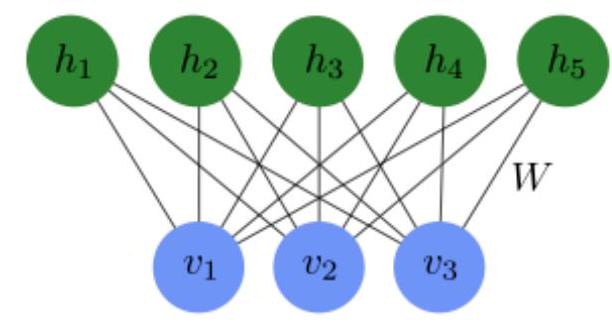
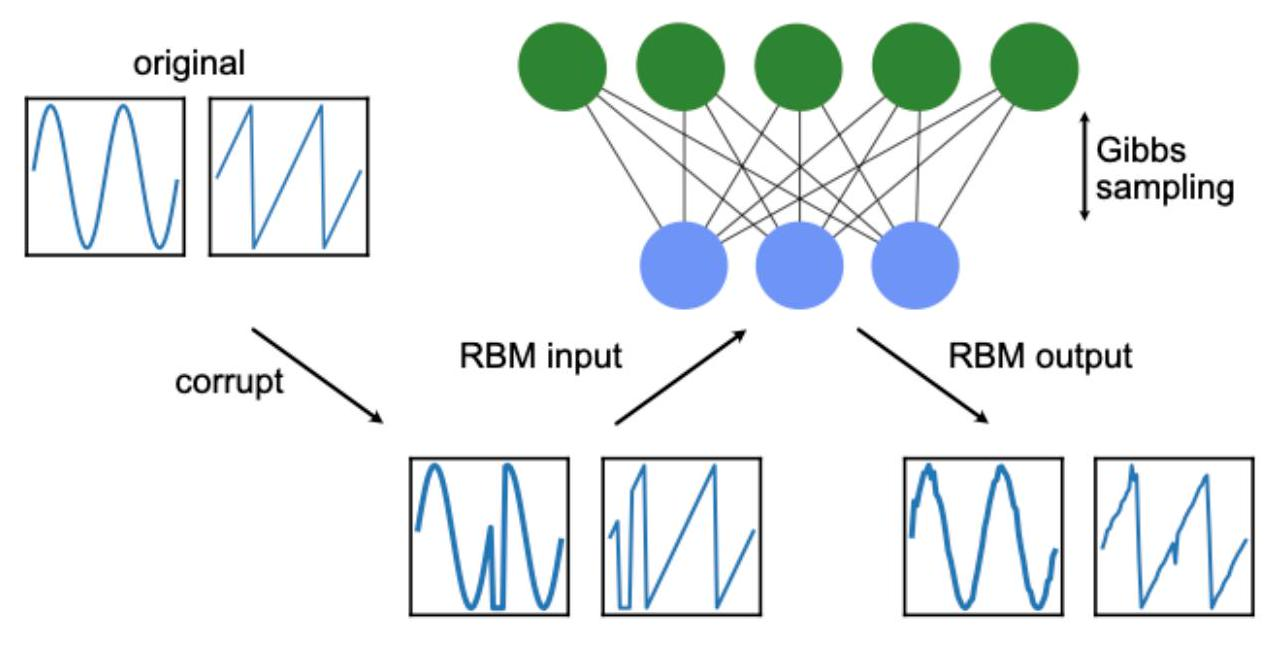
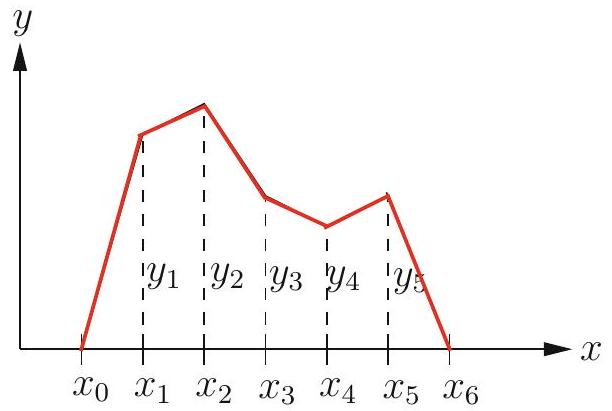

## *How to Compute an LU Factorization (no row swaps)*

**Algorithm:**

1.  Start with $U := A$ and $L := I$ (identity matrix).

2.  For each pivot column $k = 1, \ldots, n-1$:

    -   For each row $i = k+1, \ldots, n$:
        -   Compute the multiplier: $\ell_{ik} := U_{ik}/U_{kk}$
        -   Update the row in $U$: subtract $\ell_{ik}$ times row $k$
            from row $i$
        -   Store the multiplier in $L$: set $L_{ik} := \ell_{ik}$

3.  At the end, $U$ is upper triangular, $L$ is unit lower triangular,
    and $A = LU$.

**Note:** If a pivot $U_{kk}$ is zero (or you decide to swap rows), you
need a permutation matrix: $PA = LU$ (see PLU factorization section
below).

This is exactly what “store the multipliers as you go” means.

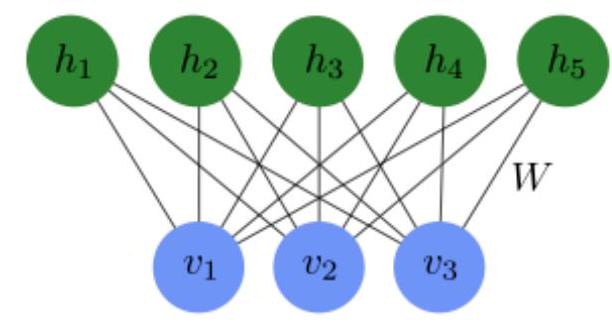
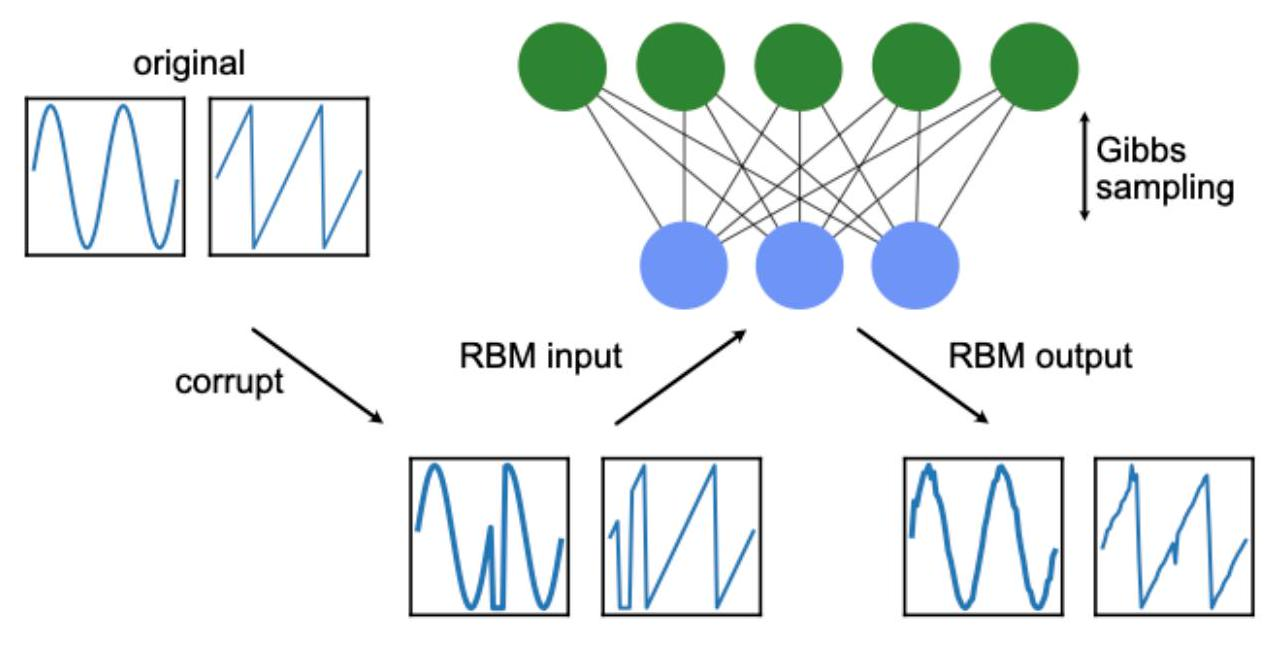
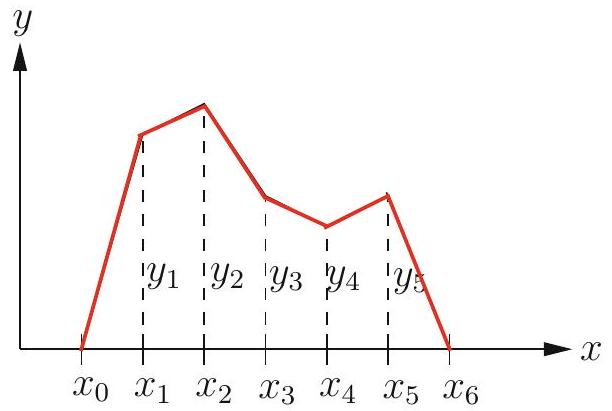

## *Steps to LU factorization*

Let $\left[a_{i j}^{(k)}\right]$ be the matrix obtained from $A$ after
using the $k$ th pivot to clear out entries below it.

. . .

(The original matrix is $A=\left[a_{i j}^{(0)}\right]$)

. . .

All the row operations we will use include ratios
$\left(-a_{i j} / a_{j j}\right)$.

. . .

The row-adding elementary operations are of the form

$E_{i j}\left(-a_{i j}^{(k)} / a_{j j}^{(k)}\right)$

. . .

We can give these ratios a name: **multipliers**.

$m_{i j}=-a_{i j}^{(k)} / a_{j j}^{(k)}$, where $i>j$

. . .

If Gaussian elimination is used without row exchanges on the nonsingular
matrix $A$, resulting in the upper triangular matrix $U$, and if $L$ is
the unit lower triangular matrix whose entries below the diagonal are
the negatives of the multipliers $m_{i j}$, then $A=L U$.

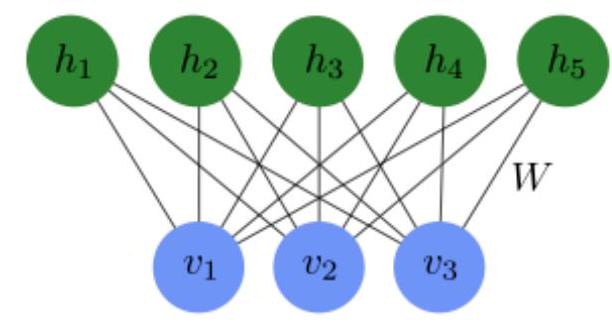
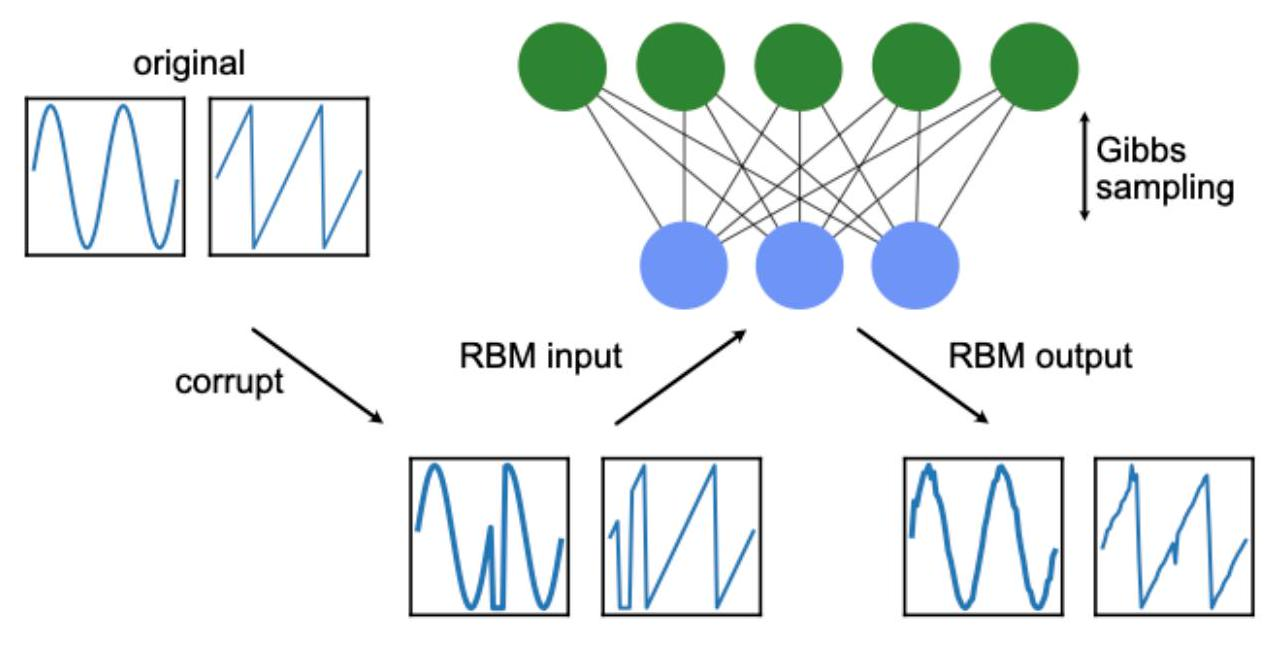
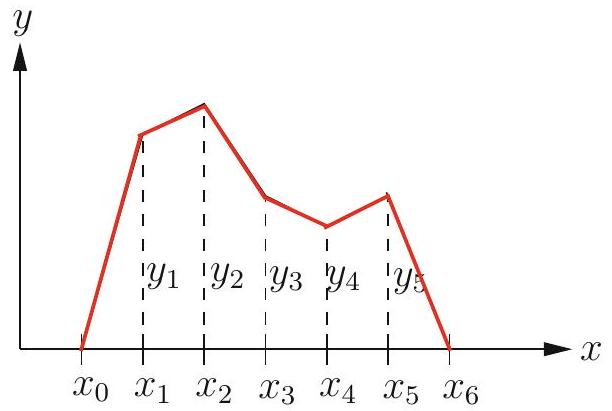

## *Storing the multipliers as we go*

For efficiency, we can just “store” the multipliers in the lower
triangular part of the matrix on the left as we go along, since that
will be zero anyways.

$$
\left[\begin{array}{rrr}
(2) & 1 & 0 \\
-2 & 0 & -1 \\
2 & 3 & -3
\end{array}\right] \xrightarrow[E_{31}(-1)]{E_{21}(1)}\left[\begin{array}{rrr}
2 & 1 & 0 \\
-1 & (1) & -1 \\
1 & 2 & -3
\end{array}\right] \xrightarrow[E_{32}(-2)]{\longrightarrow}\left[\begin{array}{rrr}
2 & 1 & 0 \\
-1 & 1 & -1 \\
1 & 2 & -1
\end{array}\right] .
$$

. . .

Now we read off the results from the final matrix:

$$
L=\left[\begin{array}{rrr}
1 & 0 & 0 \\
1 & 1 & 0 \\
-1 & 2 & 1
\end{array}\right] \text { and } U=\left[\begin{array}{rrr}
2 & 1 & 0 \\
0 & 1 & -1 \\
0 & 0 & -1
\end{array}\right]
$$

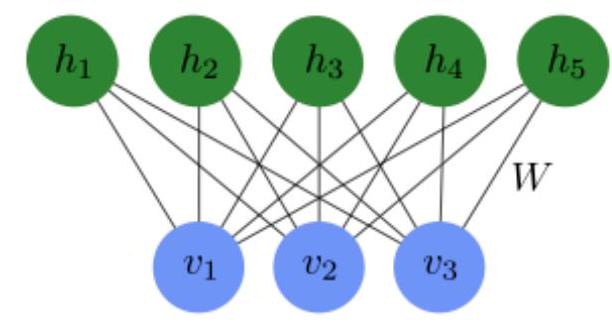
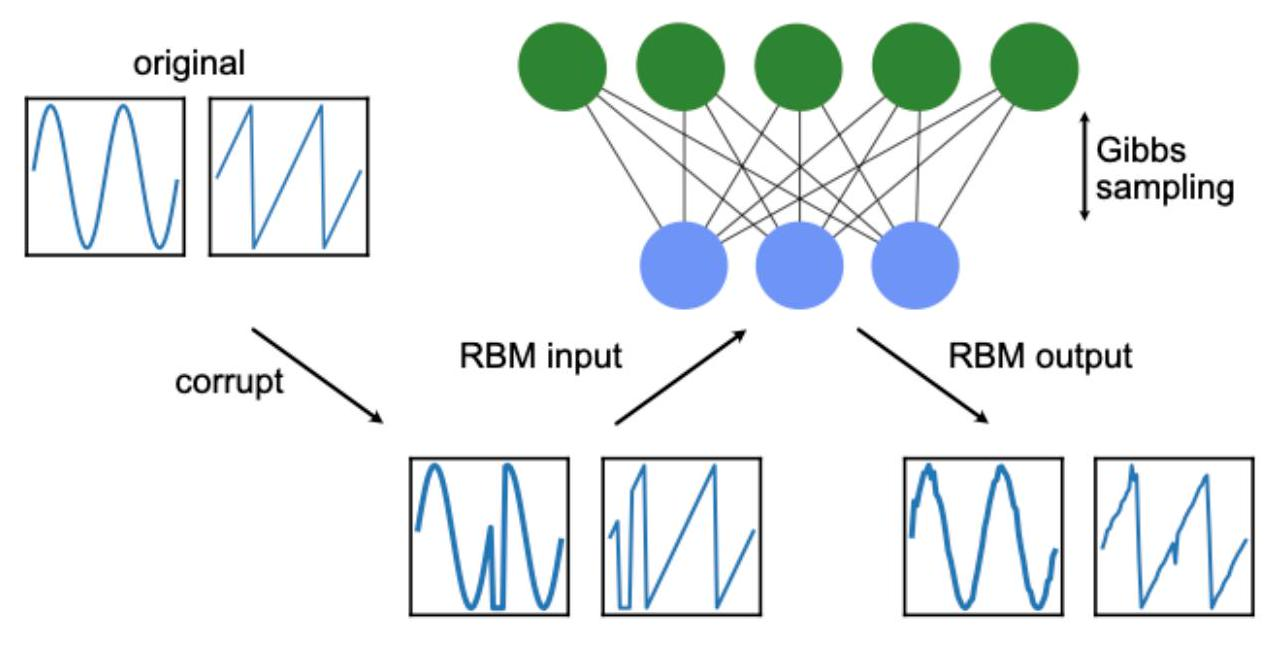
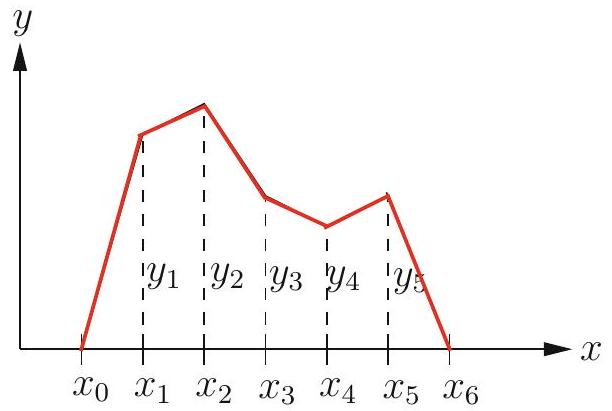

## *Superaugmented matrix*

Could we just keep track by using the superaugmented matrix, like we did
last lecture? What would that look like?

**pause**

$\left[\begin{smallmatrix}2 & 1 & 0 & 1 & 0 & 0\\-2 & 0 & -1 & 0 & 1 & 0\\2 & 3 & -3 & 0 & 0 & 1\end{smallmatrix}\right]$
$\xrightarrow[E_{31}(-1)]{E_{21}(1)}$
$\left[\begin{smallmatrix}2 & 1 & 0 & 1 & 0 & 0\\0 & 1 & -1 & 1 & 1 & 0\\0 & 2 & -3 & -1 & 0 & 1\end{smallmatrix}\right]$
$\xrightarrow[E_{32}(-2)]{\longrightarrow}$
$\left[\begin{smallmatrix}2 & 1 & 0 & 1 & 0 & 0\\0 & 1 & -1 & 1 & 1 & 0\\0 & 0 & -1 & -3 & -2 & 1\end{smallmatrix}\right]$

. . .

Our superaugmented matrix does become an upper triangular matrix on the
left and a lower triangular matrix on the right.

Unfortunately, the lower triangular matrix on the right is
$\tilde{L}^{-1}$, not $\tilde{L}$.

So we can’t just read off $L$ and $U$ from the superaugmented matrix.

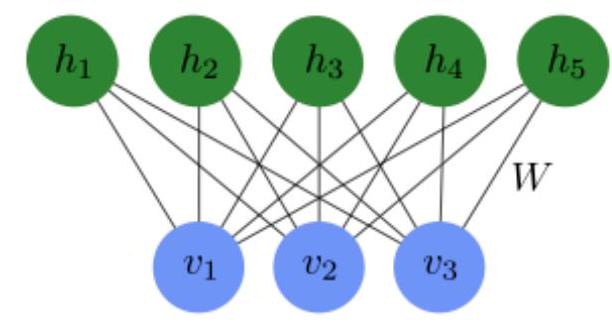
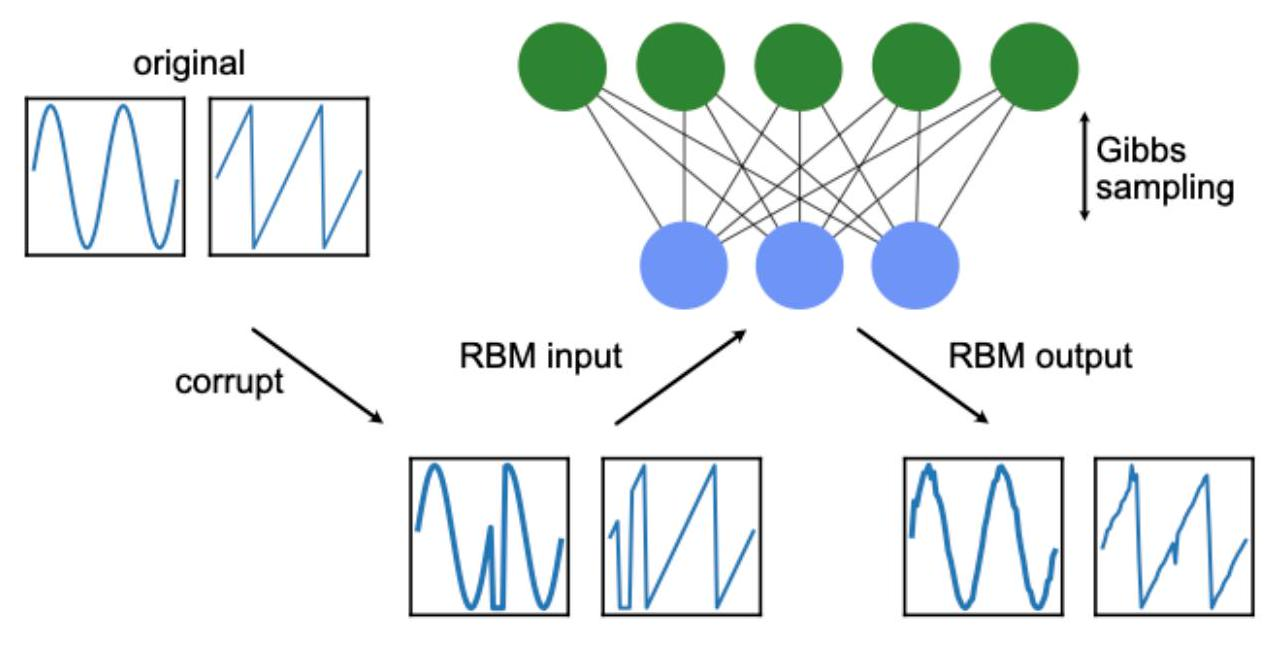
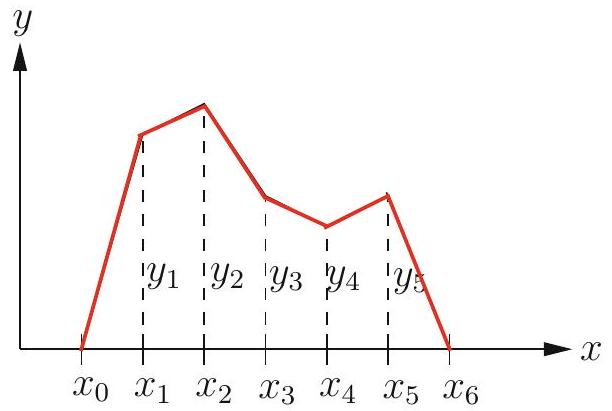

## *PLU factorization*

What if we need row exchanges?

-   We could start off by doing all the row-exchanging elementary
    operations that we need, and store the product of these
    row-exchanging matrices as a matrix $P$.

-   This product is called a **permutation matrix**

-   Applying the correct permuatation matrix $P$ to $A$, we get a matrix
    for which Gaussian elimination will succeed without further row
    exchanges.

. . .

Now we have a theorem that applies to all nonsingular matrices:

If $A$ is a nonsingular matrix, then there exists a permutation matrix
$P$, upper triangular matrix $U$, and unit lower triangular matrix $L$
such that $P A=L U$.

. . .

So, if you’ve got a nonsingular matrix $A$, you can always find a
permutation matrix $P$, an upper triangular matrix $U$, and a unit lower
triangular matrix $L$ that satisfy $P A=L U$. Pretty neat, huh?

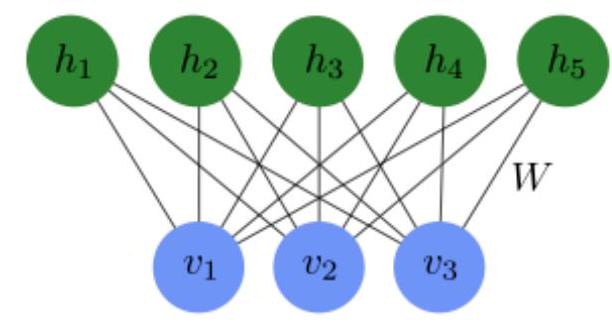
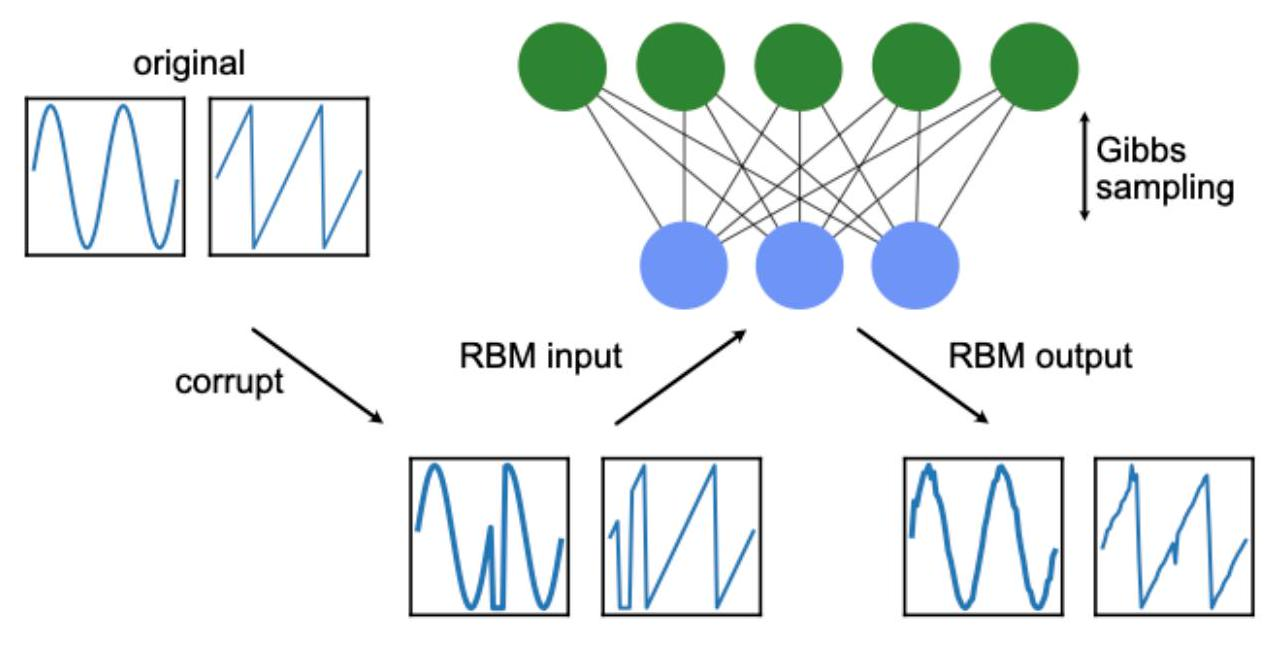
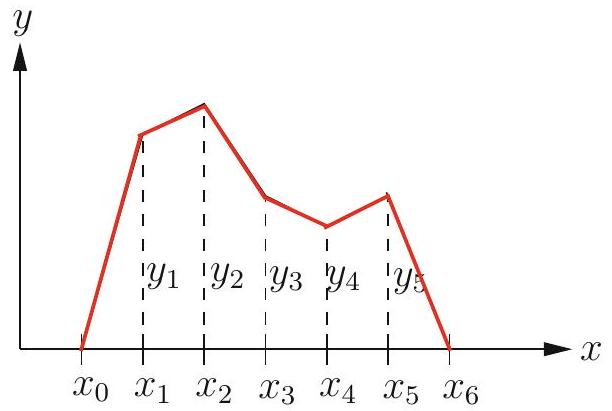